# MIT RF Challenge: Data Analysis

### Introduction

This project studies whether multivariate statistical features extracted from radio-frequency (RF) mixture signals can distinguish signal classes in the MIT RF Challenge preliminary dataset. In RF signal analysis, the observed waveform is naturally multivariate in the sense that each example contains rich joint structure across amplitude, phase, and spectral behavior. Rather than treating the problem purely as an engineering task of demodulation or source separation, the goal here is to examine what standard methods from multivariate statistics reveal about the geometry, density structure, and class separability of these signals.

The dataset considered here consists of 9,900 mixture signals drawn evenly from three classes: CommSignal2, CommSignal3, and EMISignal1. Each observation is a complex IQ waveform represented in SigMF format. From each waveform, I constructed a set of summary features describing signal amplitude, variability, peak-to-average behavior, phase dispersion, and spectral structure. These features transform each raw signal into a multivariate feature vector suitable for statistical analysis.

The main research question is: to what extent can waveform-derived summary features distinguish RF signal classes, and what linear and nonlinear low-dimensional representations reveal that class structure? To answer this question, I used principal component analysis (PCA) to study major directions of variation, kernel density estimation (KDE) to compare class-conditional feature distributions, linear and quadratic discriminant analysis (LDA/QDA) as supervised classification methods, and cross-validation to assess predictive performance. I also used UMAP and t-SNE as exploratory nonlinear embedding methods to visualize latent geometric structure in the feature space.

A key modeling issue in this dataset is that center frequency is highly informative of class membership. Indeed, including center frequency as a predictor yielded perfect cross-validated classification accuracy. Because this risks trivializing the classification problem, the primary analysis focuses on waveform-derived features excluding center frequency, with the frequency-inclusive model treated as a benchmark rather than the main scientific result.

The results show that the signal classes are substantially distinguishable from waveform statistics alone. Spectral flatness, spectral entropy, and peak-to-average power ratio emerge as especially informative features, while PCA and nonlinear embeddings reveal both class separation and within-class substructure. These findings illustrate how multivariate statistical methods can provide interpretable insight into RF mixture data beyond purely black-box predictive modeling.

### Methods
### Data

The analysis used the demod_train portion of the MIT RF Challenge preliminary release. I restricted attention to mixture signals from three balanced classes: CommSignal2, CommSignal3, and EMISignal1, with 3,300 observations per class for a total of 9,900 signals. Each signal was stored in SigMF format as a complex baseband IQ waveform with 40,960 complex samples and a sample rate of 25 MHz.

### Feature Construction

Each waveform was converted into a multivariate feature vector using summary statistics designed to capture amplitude, phase, and spectral characteristics. The features included:

RMS power
mean amplitude
amplitude standard deviation
maximum amplitude
peak-to-average power ratio (PAPR)
mean and standard deviation of the real and imaginary parts
skewness and kurtosis of the magnitude
phase standard deviation
spectral centroid
spectral flatness
spectral entropy

These features were chosen because they provide interpretable summaries of signal strength, dispersion, peakiness, and spectral complexity.

Although center frequency was available in the metadata, it was excluded from the primary analyses because it produced perfect classification accuracy and therefore obscured the more interesting question of whether waveform structure alone distinguishes the classes.

### Principal Component Analysis

I applied PCA to the standardized feature matrix in order to identify the dominant linear directions of variation in the data. Standardization was necessary because the features were measured on different scales. PCA was used both for interpretation of the main variance directions through loading vectors and for visualization of the observations in the first two principal component coordinates.

### Kernel density estimation

To study class-conditional distributional differences, I used kernel density estimation on several especially informative scalar features, including spectral entropy, spectral flatness, PAPR, and magnitude kurtosis. These density plots were used to assess how strongly the classes differed along individual waveform-derived characteristics.

### Classification methods

I compared three supervised classification methods:

Linear Discriminant Analysis (LDA)
Quadratic Discriminant Analysis (QDA)
Multinomial logistic regression

LDA assumes a common covariance structure across classes and produces linear decision boundaries. QDA relaxes this assumption by allowing each class to have its own covariance matrix, leading to quadratic decision boundaries. Multinomial logistic regression provides a linear probabilistic baseline without the Gaussian class-conditional assumptions used by LDA and QDA.

### Model Assessment

Predictive performance was evaluated using 5-fold stratified cross-validation, with classification accuracy as the main assessment metric. I also examined the cross-validated confusion matrix for LDA to identify which class pairs were most frequently confused.

### Nonlinear Visualization

To complement PCA, I used t-SNE and UMAP on PCA-reduced standardized features. These methods were used only for exploratory visualization of possible nonlinear structure and within-class subgroups; they were not treated as inferential or predictive methods.

In [32]:
# Imports for the notebook
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from scipy.stats import kurtosis, skew, entropy
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

In [33]:
# Load Data
root = Path(r"D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train")

print("Root exists:", root.exists())

all_data_files = list(root.rglob("*.sigmf-data"))
print("Number of .sigmf-data files found:", len(all_data_files))
print("First few files:")
for f in all_data_files[:10]:
    print("  ", f)

def first_or_empty(lst):
    return lst[0] if isinstance(lst, list) and len(lst) > 0 else {}

Root exists: True
Number of .sigmf-data files found: 9900
First few files:
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0000.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0001.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0002.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0003.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0004.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0005.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0006.sigmf-data
   D:\CS 6955\CS-6955\DL-AIR\mit_challenge\dataset\demod_train\CommSignal2\CommSignal2_demod_train_0007.sigmf-data
   D:

In [34]:
def load_sigmf_pair(data_path):
    meta_path = data_path.with_suffix(".sigmf-meta")

    with open(meta_path, "r") as f:
        meta = json.load(f)

    raw = np.fromfile(data_path, dtype="<f4")

    # interleaved float32 IQ: I0,Q0,I1,Q1,...
    if len(raw) % 2 != 0:
        raise ValueError(f"Odd number of float32 values in {data_path}")

    x = raw[0::2] + 1j * raw[1::2]
    return x.astype(np.complex64), meta

def first_or_empty(lst):
    return lst[0] if isinstance(lst, list) and len(lst) > 0 else {}

def infer_labels(path):
    name = path.name

    if "CommSignal2" in name:
        base_class = "CommSignal2"
    elif "CommSignal3" in name:
        base_class = "CommSignal3"
    elif "EMISignal1" in name or "EmiSignal1" in name:
        base_class = "EMISignal1"
    else:
        base_class = "unknown"

    if "(1)" in name:
        kind = "component"
    elif "(2)" in name:
        kind = "bits_ref"
    else:
        kind = "mixture"

    return base_class, kind

def extract_features(x):
    mag = np.abs(x)
    ph = np.angle(x)

    Xf = np.fft.fftshift(np.fft.fft(x))
    psd = np.abs(Xf) ** 2
    psd_sum = psd.sum()
    psd_norm = psd / psd_sum if psd_sum > 0 else np.ones_like(psd) / len(psd)

    freqs = np.linspace(-0.5, 0.5, len(x), endpoint=False)

    return {
        "n_samples": len(x),
        "rms_power": float(np.mean(mag**2)),
        "amp_mean": float(np.mean(mag)),
        "amp_std": float(np.std(mag)),
        "amp_max": float(np.max(mag)),
        "papr": float(np.max(mag**2) / (np.mean(mag**2) + 1e-12)),
        "real_mean": float(np.mean(np.real(x))),
        "imag_mean": float(np.mean(np.imag(x))),
        "real_std": float(np.std(np.real(x))),
        "imag_std": float(np.std(np.imag(x))),
        "mag_skew": float(skew(mag)),
        "mag_kurt": float(kurtosis(mag, fisher=False)),
        "phase_std": float(np.std(ph)),
        "spec_centroid": float(np.sum(freqs * psd_norm)),
        "spec_flatness": float(np.exp(np.mean(np.log(psd + 1e-12))) / (np.mean(psd) + 1e-12)),
        "spec_entropy": float(entropy(psd_norm + 1e-12)),
    }

rows = []
data_files = list(root.rglob("*.sigmf-data"))

print(f"Found {len(data_files)} signal files")

for i, data_path in enumerate(data_files):
    try:
        x, meta = load_sigmf_pair(data_path)
        base_class, kind = infer_labels(data_path)

        global_meta = meta.get("global", {})
        capture0 = first_or_empty(meta.get("captures", []))
        annotation0 = first_or_empty(meta.get("annotations", []))

        row = {
            "filename": data_path.name,
            "relative_path": str(data_path.relative_to(root)),
            "base_class": base_class,
            "kind": kind,
            "sample_rate": global_meta.get("core:sample_rate"),
            "center_freq": capture0.get("core:frequency"),
            "description": annotation0.get("core:description"),
        }

        row.update(extract_features(x))
        rows.append(row)

        if i < 3:
            print("Loaded OK:", data_path.name)
            print("  captures len:", len(meta.get("captures", [])))
            print("  annotations len:", len(meta.get("annotations", [])))

    except Exception as e:
        print(f"Error with {data_path}: {e}")

df = pd.DataFrame(rows)
print("Final dataframe shape:", df.shape)
print(df.head())

df.to_csv("demod_train_features.csv", index=False)

Found 9900 signal files
Loaded OK: CommSignal2_demod_train_0000.sigmf-data
  captures len: 1
  annotations len: 0
Loaded OK: CommSignal2_demod_train_0001.sigmf-data
  captures len: 1
  annotations len: 0
Loaded OK: CommSignal2_demod_train_0002.sigmf-data
  captures len: 1
  annotations len: 0
Final dataframe shape: (9900, 23)
                                  filename  \
0  CommSignal2_demod_train_0000.sigmf-data   
1  CommSignal2_demod_train_0001.sigmf-data   
2  CommSignal2_demod_train_0002.sigmf-data   
3  CommSignal2_demod_train_0003.sigmf-data   
4  CommSignal2_demod_train_0004.sigmf-data   

                                       relative_path   base_class     kind  \
0  CommSignal2\CommSignal2_demod_train_0000.sigmf...  CommSignal2  mixture   
1  CommSignal2\CommSignal2_demod_train_0001.sigmf...  CommSignal2  mixture   
2  CommSignal2\CommSignal2_demod_train_0002.sigmf...  CommSignal2  mixture   
3  CommSignal2\CommSignal2_demod_train_0003.sigmf...  CommSignal2  mixture   
4  Co

In [35]:
first_20_data_files = list(root.rglob("*.sigmf-data"))[:20]

In [36]:
print(df.shape)
print(df[["filename", "base_class", "kind", "sample_rate", "center_freq", "description"]].head())

print(df["base_class"].value_counts())
print(df["kind"].value_counts())
print(df.groupby(["base_class", "kind"]).size())

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)
print(df[numeric_cols].describe().T)

(9900, 23)
                                  filename   base_class     kind  sample_rate  \
0  CommSignal2_demod_train_0000.sigmf-data  CommSignal2  mixture   25000000.0   
1  CommSignal2_demod_train_0001.sigmf-data  CommSignal2  mixture   25000000.0   
2  CommSignal2_demod_train_0002.sigmf-data  CommSignal2  mixture   25000000.0   
3  CommSignal2_demod_train_0003.sigmf-data  CommSignal2  mixture   25000000.0   
4  CommSignal2_demod_train_0004.sigmf-data  CommSignal2  mixture   25000000.0   

    center_freq description  
0  2.437000e+09        None  
1  2.437000e+09        None  
2  2.437000e+09        None  
3  2.437000e+09        None  
4  2.437000e+09        None  
base_class
CommSignal2    3300
CommSignal3    3300
EMISignal1     3300
Name: count, dtype: int64
kind
mixture    9900
Name: count, dtype: int64
base_class   kind   
CommSignal2  mixture    3300
CommSignal3  mixture    3300
EMISignal1   mixture    3300
dtype: int64
['sample_rate', 'center_freq', 'n_samples', 'rms_power', 

In [37]:
feature_cols_no_cf = [
    "rms_power",
    "amp_mean",
    "amp_std",
    "amp_max",
    "papr",
    "real_mean",
    "imag_mean",
    "real_std",
    "imag_std",
    "mag_skew",
    "mag_kurt",
    "phase_std",
    "spec_centroid",
    "spec_flatness",
    "spec_entropy",
]

feature_cols_with_cf = ["center_freq"] + feature_cols_no_cf

# Signal Analysis

# PCA

In [38]:
X = df[feature_cols_no_cf].copy().dropna()
y = df.loc[X.index, "base_class"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
Z = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print("First 10 explained variance ratios:")
print(explained[:10])
print("Cumulative:")
print(np.cumsum(explained[:10]))

First 10 explained variance ratios:
[0.47554726 0.15125633 0.10030527 0.08472127 0.06615055 0.06385138
 0.02229126 0.01422064 0.01008922 0.00598892]
Cumulative:
[0.47554726 0.62680359 0.72710886 0.81183013 0.87798068 0.94183206
 0.96412332 0.97834396 0.98843318 0.9944221 ]


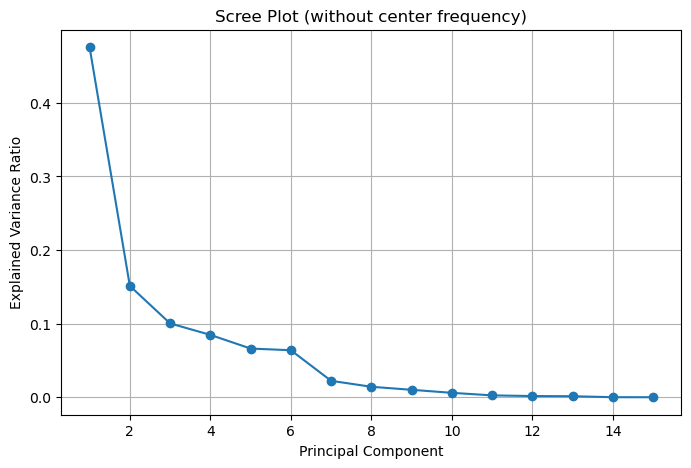

In [39]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained)+1), explained, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot (without center frequency)")
plt.grid(True)
plt.show()

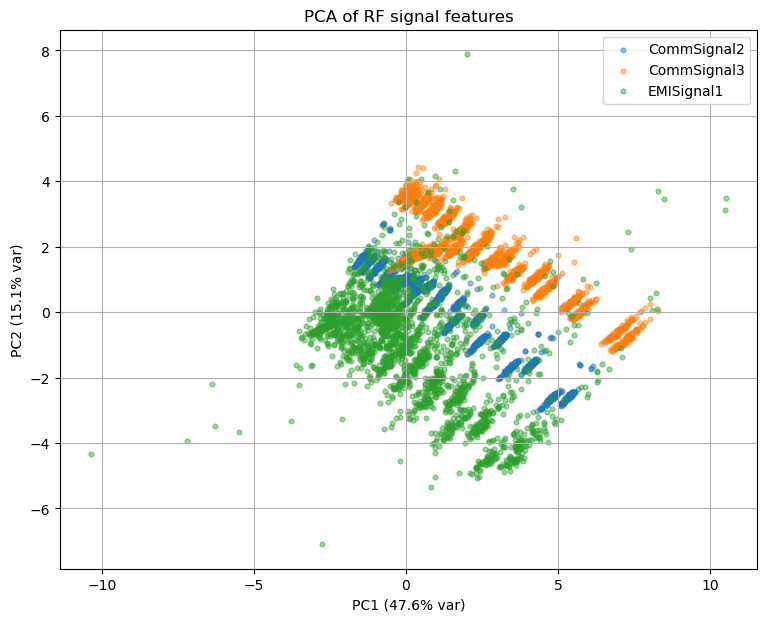

In [40]:
X = df[feature_cols_no_cf].copy().dropna()
y = df.loc[X.index, "base_class"]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": Z[:, 0],
    "PC2": Z[:, 1],
    "base_class": y.values
})

plt.figure(figsize=(9, 7))
for cls in pca_df["base_class"].unique():
    idx = pca_df["base_class"] == cls
    plt.scatter(
        pca_df.loc[idx, "PC1"],
        pca_df.loc[idx, "PC2"],
        s=12,
        alpha=0.45,
        label=cls
    )

plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}% var)")
plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}% var)")
plt.title("PCA of RF signal features")
plt.legend()
plt.grid(True)
plt.show()

The PCA projection reveals partial separation but also substantial overlap, indicating that the class structure is not fully linearly separable in the first two principal directions. At the same time, the classes exhibit distinct banded substructures, suggesting latent within-class regimes or repeated waveform configurations.

* Is PC1 mostly power/amplitude variation?
* Is PC2 mostly spectral structure?
* Is one PC mostly phase variability?
* Do CommSignal2, CommSignal3, and EMISignal1 separate along those directions?

The first principal component is primarily associated with overall signal magnitude and variability, with the strongest loadings on peak amplitude, amplitude dispersion, in-phase and quadrature standard deviations, and RMS power. The second principal component is driven more by peak-to-average ratio and spectral complexity, as reflected by strong loadings on PAPR, spectral entropy, and spectral flatness. Thus, the dominant axes of variation separate overall energy/dispersion effects from waveform-shape and spectral-structure effects.

In [41]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols_no_cf,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

print("Top absolute loadings for PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False))

print("\nTop absolute loadings for PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False))

Top absolute loadings for PC1:
amp_max          0.354639
amp_std          0.344229
imag_std         0.334230
real_std         0.334011
rms_power        0.320677
amp_mean         0.318454
mag_skew         0.275157
spec_flatness    0.269365
papr             0.239895
phase_std        0.212879
spec_entropy     0.207758
mag_kurt         0.176466
imag_mean        0.039735
real_mean        0.028638
spec_centroid    0.019480
Name: PC1, dtype: float64

Top absolute loadings for PC2:
papr             0.433090
spec_entropy     0.395534
spec_flatness    0.392896
amp_mean         0.336355
rms_power        0.322911
mag_skew         0.302510
real_std         0.295431
imag_std         0.294855
phase_std        0.094465
mag_kurt         0.077341
spec_centroid    0.050777
real_mean        0.020067
imag_mean        0.017769
amp_std          0.013664
amp_max          0.009596
Name: PC2, dtype: float64


# Boxplots for features

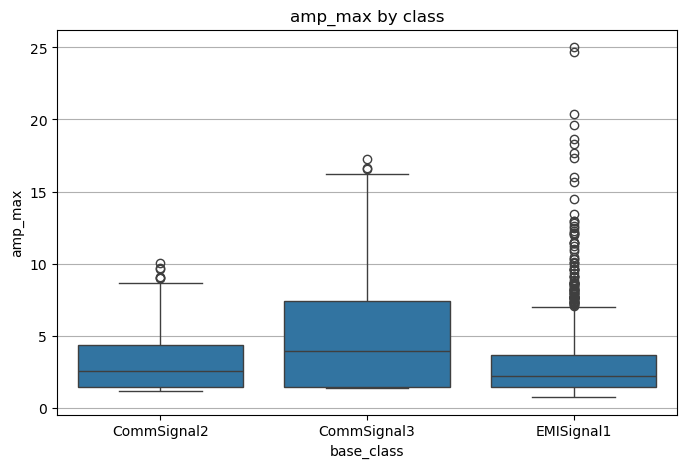

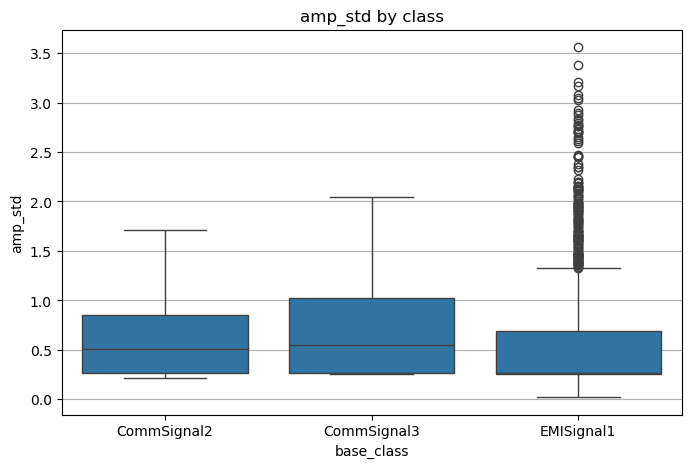

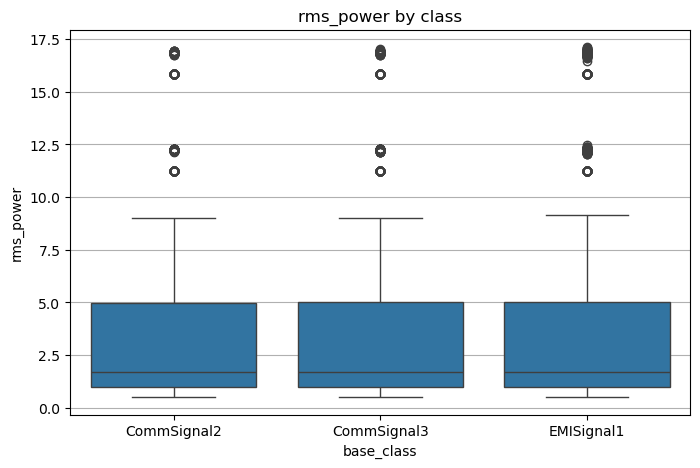

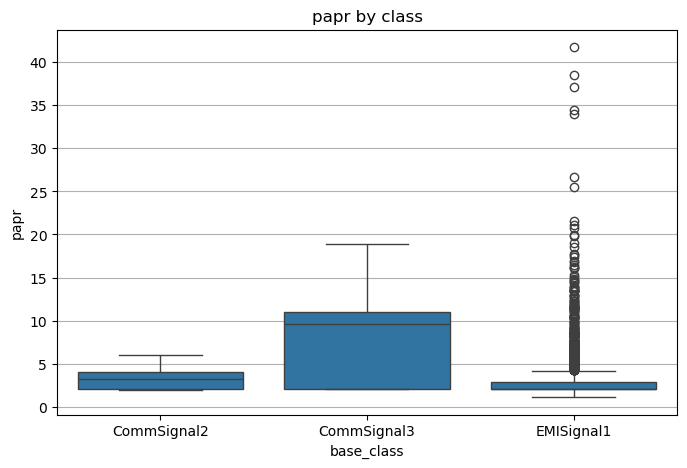

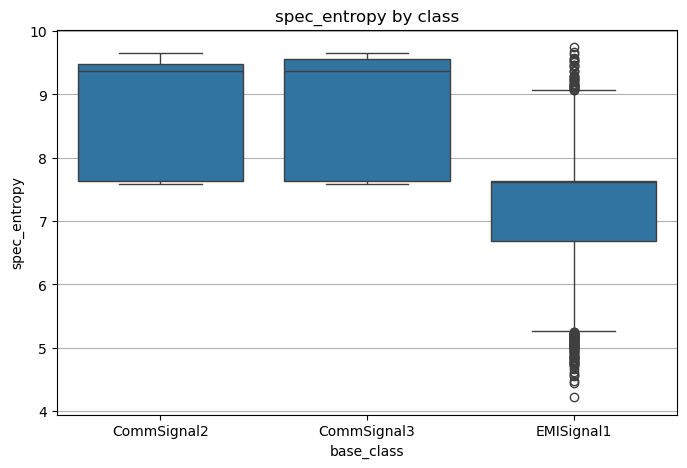

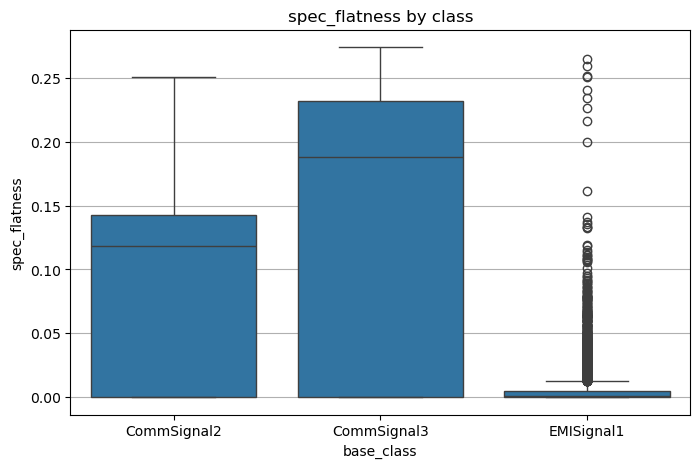

In [42]:
for feat in ["amp_max", "amp_std", "rms_power", "papr", "spec_entropy", "spec_flatness"]:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x="base_class", y=feat)
    plt.title(f"{feat} by class")
    plt.grid(True, axis="y")
    plt.show()

# KDE of features

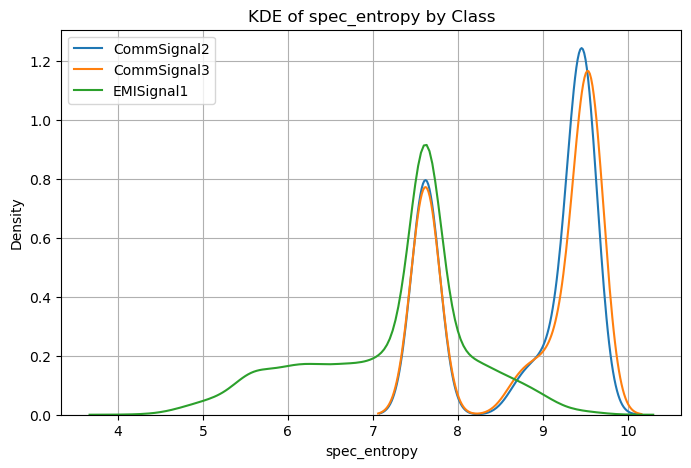

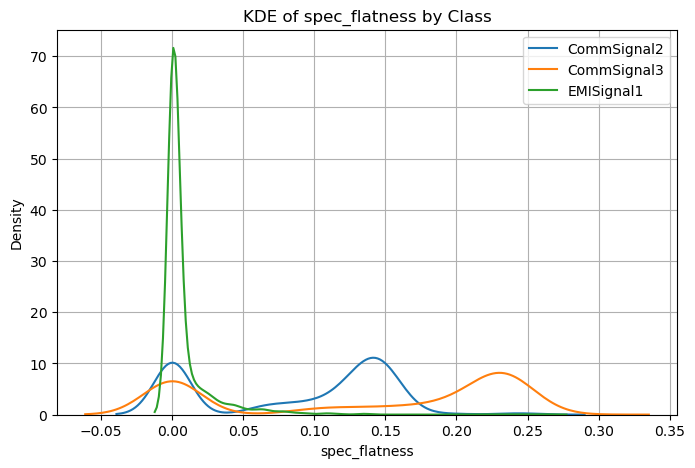

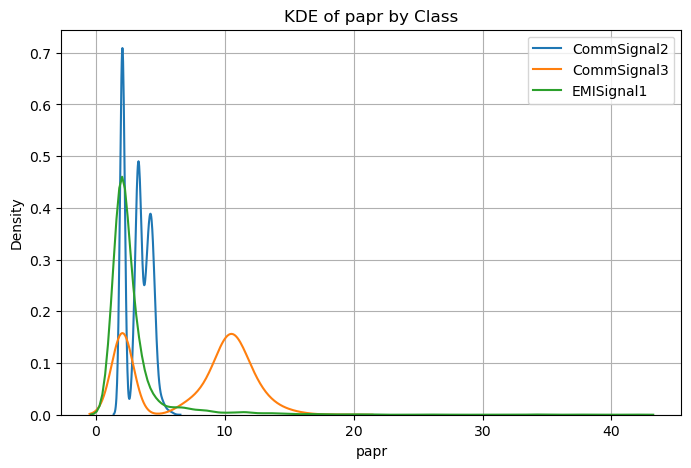

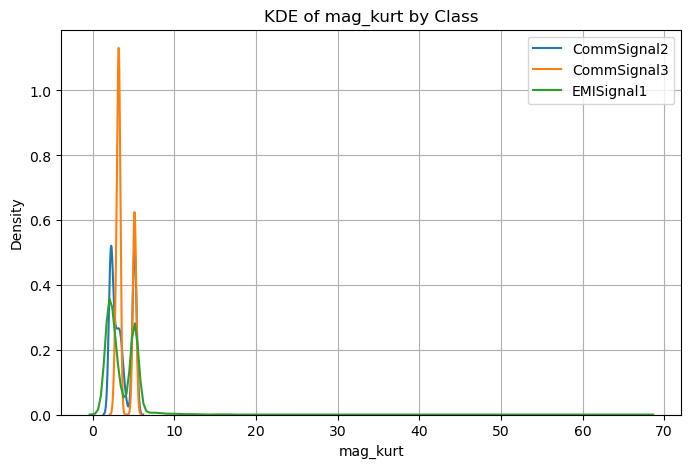

In [43]:
for feat in ["spec_entropy", "spec_flatness", "papr", "mag_kurt"]:
    plt.figure(figsize=(8,5))
    for cls in df["base_class"].unique():
        sns.kdeplot(
            data=df[df["base_class"] == cls],
            x=feat,
            label=cls,
            fill=False
        )
    plt.title(f"KDE of {feat} by Class")
    plt.grid(True)
    plt.legend()
    plt.show()

# Cross Validation of LDA

In [44]:
X_cls = df[feature_cols_no_cf].copy().dropna()
y_cls = df.loc[X_cls.index, "base_class"]

lda = LinearDiscriminantAnalysis()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(lda, X_cls, y_cls, cv=cv, scoring="accuracy")

print("LDA CV accuracy (without center_freq):")
print("mean =", scores.mean())
print("std  =", scores.std())
print("scores =", scores)

LDA CV accuracy (without center_freq):
mean = 0.7696969696969697
std  = 0.009034618090908237
scores = [0.78686869 0.76212121 0.76616162 0.76313131 0.77020202]


In [45]:
X_cls_cf = df[feature_cols_with_cf].copy().dropna()
y_cls_cf = df.loc[X_cls_cf.index, "base_class"]

scores_cf = cross_val_score(lda, X_cls_cf, y_cls_cf, cv=cv, scoring="accuracy")

print("LDA CV accuracy (with center_freq):")
print("mean =", scores_cf.mean())
print("std  =", scores_cf.std())
print("scores =", scores_cf)

LDA CV accuracy (with center_freq):
mean = 1.0
std  = 0.0
scores = [1. 1. 1. 1. 1.]


# LDA

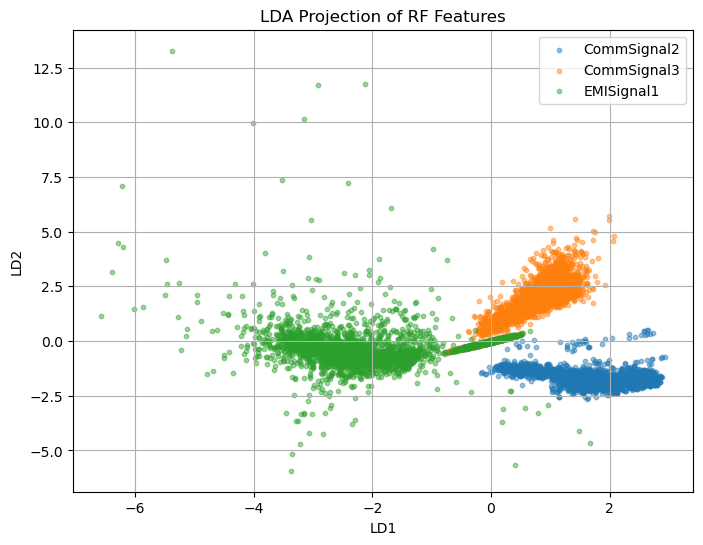

In [46]:
lda_fit = LinearDiscriminantAnalysis(n_components=2)
Z_lda = lda_fit.fit_transform(X_cls, y_cls)

lda_df = pd.DataFrame({
    "LD1": Z_lda[:, 0],
    "LD2": Z_lda[:, 1],
    "base_class": y_cls.values
})

plt.figure(figsize=(8,6))
for cls in lda_df["base_class"].unique():
    idx = lda_df["base_class"] == cls
    plt.scatter(
        lda_df.loc[idx, "LD1"],
        lda_df.loc[idx, "LD2"],
        alpha=0.45,
        s=10,
        label=cls
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA Projection of RF Features")
plt.legend()
plt.grid(True)
plt.show()

# QDA

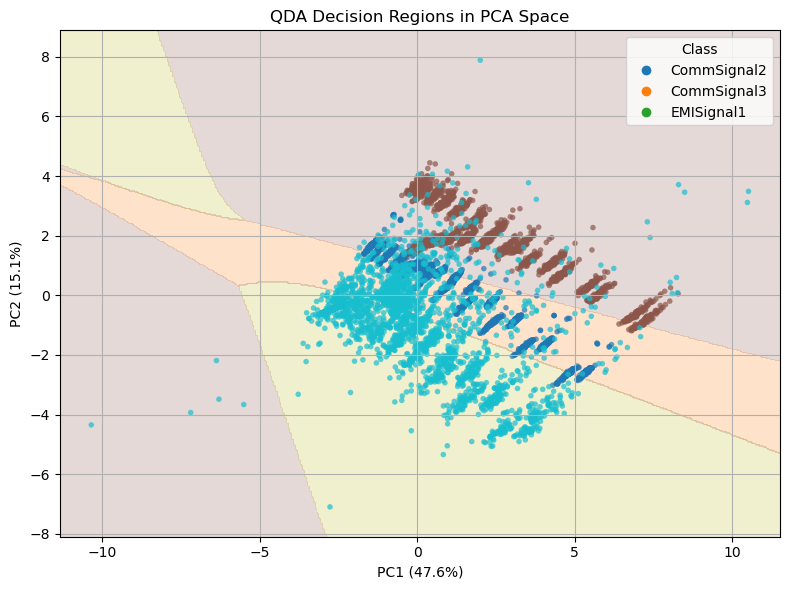

In [47]:
X_cls = df[feature_cols_no_cf].copy().dropna()
y_cls = df.loc[X_cls.index, "base_class"]

# Fit scaler + PCA for visualization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cls)

pca2 = PCA(n_components=2)
Z = pca2.fit_transform(X_scaled)

qda_2d = QuadraticDiscriminantAnalysis()
qda_2d.fit(Z, y_cls)

# Mesh grid
x_min, x_max = Z[:, 0].min() - 1.0, Z[:, 0].max() + 1.0
y_min, y_max = Z[:, 1].min() - 1.0, Z[:, 1].max() + 1.0
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]
pred_grid = qda_2d.predict(grid)

classes = np.unique(y_cls)
class_to_int = {c: i for i, c in enumerate(classes)}
Z_grid = np.array([class_to_int[c] for c in pred_grid]).reshape(xx.shape)
y_num = np.array([class_to_int[c] for c in y_cls])

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z_grid, alpha=0.22, levels=np.arange(len(classes)+1)-0.5, cmap="tab10")
scatter = plt.scatter(Z[:, 0], Z[:, 1], c=y_num, s=16, alpha=0.7, cmap="tab10", edgecolor="none")

handles = []
for cls, idx in class_to_int.items():
    handles.append(plt.Line2D([], [], marker='o', linestyle='', color=plt.cm.tab10(idx), label=cls))
plt.legend(handles=handles, title="Class")

plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
plt.title("QDA Decision Regions in PCA Space")
plt.grid(True)
plt.tight_layout()
plt.show()

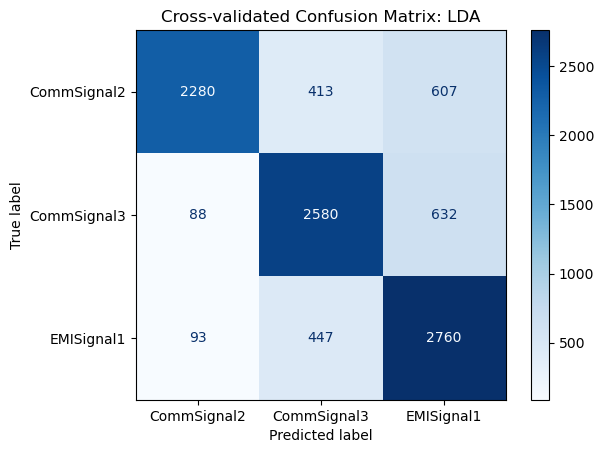

In [48]:
y_pred = cross_val_predict(lda, X_cls, y_cls, cv=cv)

cm = confusion_matrix(y_cls, y_pred, labels=sorted(y_cls.unique()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_cls.unique()))
disp.plot(cmap="Blues")
plt.title("Cross-validated Confusion Matrix: LDA")
plt.show()

t-SNE

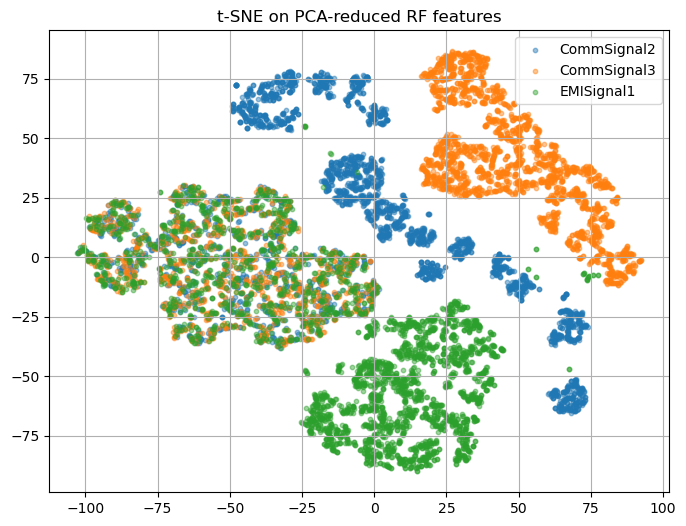

In [49]:
X_scaled = StandardScaler().fit_transform(df[feature_cols_no_cf])
pca_8 = PCA(n_components=8)
X_pca8 = pca_8.fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
T = tsne.fit_transform(X_pca8)

tsne_df = pd.DataFrame({
    "TSNE1": T[:, 0],
    "TSNE2": T[:, 1],
    "base_class": df["base_class"].values
})

plt.figure(figsize=(8,6))
for cls in tsne_df["base_class"].unique():
    idx = tsne_df["base_class"] == cls
    plt.scatter(
        tsne_df.loc[idx, "TSNE1"],
        tsne_df.loc[idx, "TSNE2"],
        alpha=0.45,
        s=10,
        label=cls
    )
plt.title("t-SNE on PCA-reduced RF features")
plt.legend()
plt.grid(True)
plt.show()

UMAP

d:\Anaconda\envs\imitation_learning\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


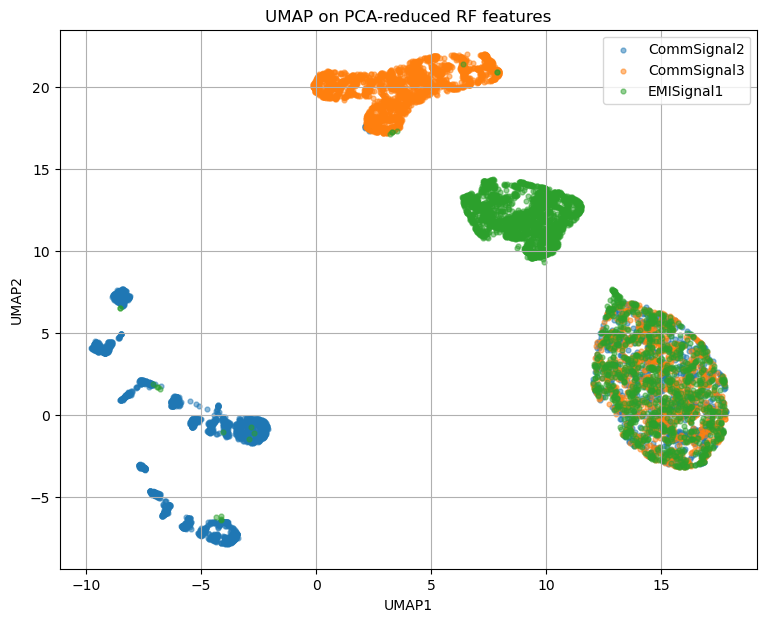

In [50]:
X = df[feature_cols_no_cf].copy().dropna()
y = df.loc[X.index, "base_class"].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=min(10, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)


reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.15,
    metric="euclidean",
    random_state=42
)

U = reducer.fit_transform(X_pca)

umap_df = pd.DataFrame({
    "UMAP1": U[:, 0],
    "UMAP2": U[:, 1],
    "base_class": y.values
})

plt.figure(figsize=(9, 7))
for cls in umap_df["base_class"].unique():
    idx = umap_df["base_class"] == cls
    plt.scatter(
        umap_df.loc[idx, "UMAP1"],
        umap_df.loc[idx, "UMAP2"],
        s=12,
        alpha=0.5,
        label=cls
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP on PCA-reduced RF features")
plt.legend()
plt.grid(True)
plt.show()

In [51]:
X_cls = df[feature_cols_no_cf].copy().dropna()
y_cls = df.loc[X_cls.index, "base_class"]

logreg = LogisticRegression(
    max_iter=5000,
    multi_class="multinomial"
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_log = cross_val_score(logreg, X_cls, y_cls, cv=cv, scoring="accuracy")

print("Multinomial logistic CV accuracy:")
print("mean =", scores_log.mean())
print("std  =", scores_log.std())
print("scores =", scores_log)

d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
d:\Anaconda\envs\imitation_learning\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWar

Multinomial logistic CV accuracy:
mean = 0.7624242424242424
std  = 0.0035511910770195635
scores = [0.76515152 0.76515152 0.76565657 0.75808081 0.75808081]


# Predictive Modeling

## Q: Can multivariate features predict source/interference class or decoding success?
* Logistic Regression
* Ridge Regression
* Cross-Validation



In [52]:
results_summary = pd.DataFrame({
    "Model": [
        "LDA (no center_freq)",
        "QDA (no center_freq)",
        "Multinomial Logistic (no center_freq)",
        "LDA (with center_freq)"
    ],
    "Mean CV Accuracy": [
        0.7696969696969697,
        0.775959595959596,
        0.7624242424242424,
        1.0
    ],
    "Std CV Accuracy": [
        0.009034618090908237,
        0.00957520349588208,
        0.0035511910770195635,
        0.0
    ]
})

results_summary["Mean CV Accuracy"] = results_summary["Mean CV Accuracy"].round(4)
results_summary["Std CV Accuracy"] = results_summary["Std CV Accuracy"].round(4)

print(results_summary)

                                   Model  Mean CV Accuracy  Std CV Accuracy
0                   LDA (no center_freq)            0.7697           0.0090
1                   QDA (no center_freq)            0.7760           0.0096
2  Multinomial Logistic (no center_freq)            0.7624           0.0036
3                 LDA (with center_freq)            1.0000           0.0000


In [53]:
top_feats = ["spec_flatness", "spec_entropy", "papr", "amp_max"]

class_summary_mean = df.groupby("base_class")[top_feats].mean().round(4)
class_summary_std = df.groupby("base_class")[top_feats].std().round(4)

print("Classwise means:")
print(class_summary_mean)

print("\nClasswise standard deviations:")
print(class_summary_std)

Classwise means:
             spec_flatness  spec_entropy    papr  amp_max
base_class                                               
CommSignal2         0.0870        8.7852  3.2329   3.1917
CommSignal3         0.1374        8.8123  7.7343   5.0307
EMISignal1          0.0083        7.2680  2.8413   2.8242

Classwise standard deviations:
             spec_flatness  spec_entropy    papr  amp_max
base_class                                               
CommSignal2         0.0663        0.8431  0.9476   1.9951
CommSignal3         0.1033        0.8691  4.2552   3.7763
EMISignal1          0.0209        0.9327  2.5852   2.0336


# Part B: Separation / Recovery Analysis

These cells consume the MATLAB/Octave debug artifacts written by `sourceCode/evalDebugMain.m` and `evaluateSeparation_debug.m`. The CSV files give one row per frame and one row per separated output; the MAT files retain the symbol-level payload arrays for constellation inspection.

In [54]:
from scipy.io import loadmat

challenge_root = root.parents[1] if "root" in globals() else Path.cwd()
if challenge_root.name != "mit_challenge":
    candidate = challenge_root / "mit_challenge"
    if candidate.exists():
        challenge_root = candidate

debug_root = challenge_root / "debugEval"
per_frame_files = sorted(debug_root.glob("*_perFrame.csv"))
per_output_files = sorted(debug_root.glob("*_perOutput.csv"))
debug_mat_files = sorted(debug_root.glob("*_debug.mat"))

print("Challenge root:", challenge_root)
print("Debug root:", debug_root)
print("Debug root exists:", debug_root.exists())
print("Per-frame CSV files:", len(per_frame_files))
print("Per-output CSV files:", len(per_output_files))
print("Debug MAT files:", len(debug_mat_files))

Challenge root: D:\CS 6955\CS-6955\DL-AIR\mit_challenge
Debug root: D:\CS 6955\CS-6955\DL-AIR\mit_challenge\debugEval
Debug root exists: True
Per-frame CSV files: 15
Per-output CSV files: 15
Debug MAT files: 15


In [55]:
required_recovery_vars = ["sep_frame_df", "sep_output_df", "recovery_feature_df"]
if all(name in globals() for name in required_recovery_vars):
    print(sep_frame_df.shape)
    print(sep_output_df.shape)
    print(recovery_feature_df.shape)
    display(recovery_feature_df.head())
    print(recovery_feature_df["success"].value_counts(dropna=False))
else:
    print("Recovery tables are loaded in the recovery-side analysis section below.")

Recovery tables are loaded in the recovery-side analysis section below.


In [56]:
def load_debug_csvs(paths):
    if not paths:
        return pd.DataFrame()

    frames = []
    for path in paths:
        part = pd.read_csv(path)
        part["source_file"] = path.name
        frames.append(part)

    return pd.concat(frames, ignore_index=True)


sep_frame_df = load_debug_csvs(per_frame_files)
sep_output_df = load_debug_csvs(per_output_files)

integer_cols = [
    "alphaIndex",
    "frameLen",
    "setIndex",
    "frame_number",
    "best_output_index",
    "output_index",
    "success",
]

for table in [sep_frame_df, sep_output_df]:
    for col in integer_cols:
        if col in table.columns:
            table[col] = pd.to_numeric(table[col], errors="coerce").astype("Int64")

if sep_frame_df.empty:
    print("No separation debug CSV files found yet.")
    print("Run evalDebugMain.m from mit_challenge/sourceCode after restoring mixtureData and soiParamFiles.")
else:
    print("Per-frame rows:", sep_frame_df.shape)
    print("Per-output rows:", sep_output_df.shape)
    display(sep_frame_df.head())
    display(sep_output_df.head())

Per-frame rows: (1500, 8)
Per-output rows: (3000, 12)


,alphaIndex,frameLen,setIndex,frame_number,best_output_index,best_num_errors,success,source_file
0,10,4,1,1,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
1,10,4,1,2,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
2,10,4,1,3,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
3,10,4,1,4,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
4,10,4,1,5,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv


,alphaIndex,frameLen,setIndex,frame_number,output_index,numErrors,success,payload_mean_abs,payload_std_abs,payload_phase_std,payload_power_mean,source_file
0,10,4,1,1,1,0,1,0.973549,0.232385,1.529508,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
1,10,4,1,1,2,7,0,0.873792,0.494613,1.956597,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
2,10,4,1,2,1,0,1,0.984177,0.180218,2.153285,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
3,10,4,1,2,2,4,0,0.925038,0.386369,2.179054,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
4,10,4,1,3,1,0,1,0.987049,0.163165,1.851892,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv


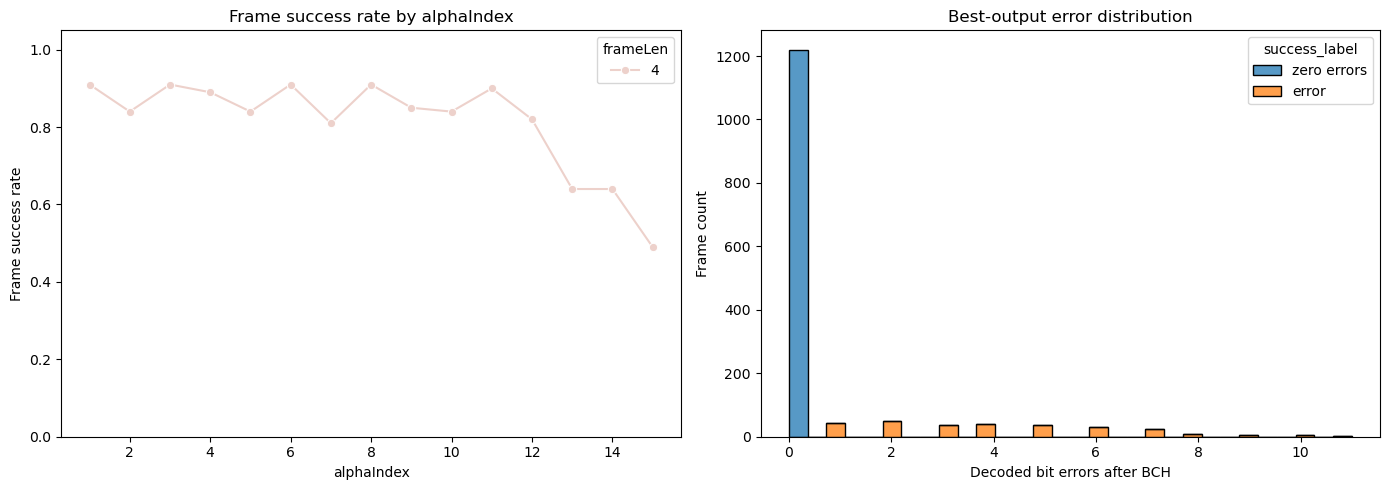

,frameLen,alphaIndex,frame_success_rate,mean_best_errors,n_frames
0,4,1,0.91,0.26,100
1,4,2,0.84,0.72,100
2,4,3,0.91,0.41,100
3,4,4,0.89,0.61,100
4,4,5,0.84,0.77,100
5,4,6,0.91,0.37,100
6,4,7,0.81,0.78,100
7,4,8,0.91,0.31,100
8,4,9,0.85,0.53,100
9,4,10,0.84,0.59,100


In [57]:
if sep_frame_df.empty:
    print("Frame-level recovery plots will populate after debug CSVs are generated.")
else:
    frame_plot_df = sep_frame_df.copy()
    frame_plot_df["success_label"] = frame_plot_df["success"].map({0: "error", 1: "zero errors"})

    alpha_summary = (
        frame_plot_df
        .groupby(["frameLen", "alphaIndex"], as_index=False)
        .agg(
            frame_success_rate=("success", "mean"),
            mean_best_errors=("best_num_errors", "mean"),
            n_frames=("frame_number", "count"),
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if alpha_summary["alphaIndex"].nunique() > 1:
        sns.lineplot(
            data=alpha_summary,
            x="alphaIndex",
            y="frame_success_rate",
            hue="frameLen",
            marker="o",
            ax=axes[0],
        )
    else:
        sns.barplot(
            data=alpha_summary,
            x="alphaIndex",
            y="frame_success_rate",
            hue="frameLen",
            ax=axes[0],
        )

    axes[0].set_title("Frame success rate by alphaIndex")
    axes[0].set_xlabel("alphaIndex")
    axes[0].set_ylabel("Frame success rate")
    axes[0].set_ylim(0, 1.05)

    sns.histplot(
        data=frame_plot_df,
        x="best_num_errors",
        hue="success_label",
        multiple="stack",
        bins=30,
        ax=axes[1],
    )
    axes[1].set_title("Best-output error distribution")
    axes[1].set_xlabel("Decoded bit errors after BCH")
    axes[1].set_ylabel("Frame count")

    plt.tight_layout()
    plt.show()

    display(alpha_summary.head(10))

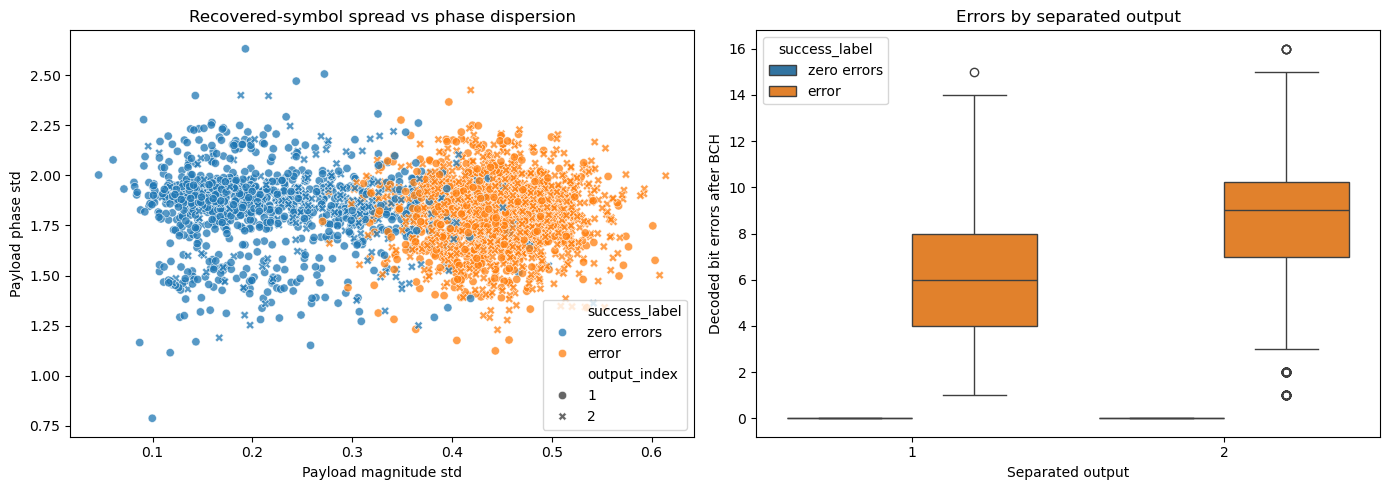

In [58]:
if sep_output_df.empty:
    print("Per-output constellation summary plots will populate after debug CSVs are generated.")
else:
    output_plot_df = sep_output_df.copy()
    output_plot_df["success_label"] = output_plot_df["success"].map({0: "error", 1: "zero errors"})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.scatterplot(
        data=output_plot_df,
        x="payload_std_abs",
        y="payload_phase_std",
        hue="success_label",
        style="output_index",
        alpha=0.75,
        ax=axes[0],
    )
    axes[0].set_title("Recovered-symbol spread vs phase dispersion")
    axes[0].set_xlabel("Payload magnitude std")
    axes[0].set_ylabel("Payload phase std")

    sns.boxplot(
        data=output_plot_df,
        x="output_index",
        y="numErrors",
        hue="success_label",
        ax=axes[1],
    )
    axes[1].set_title("Errors by separated output")
    axes[1].set_xlabel("Separated output")
    axes[1].set_ylabel("Decoded bit errors after BCH")

    plt.tight_layout()
    plt.show()

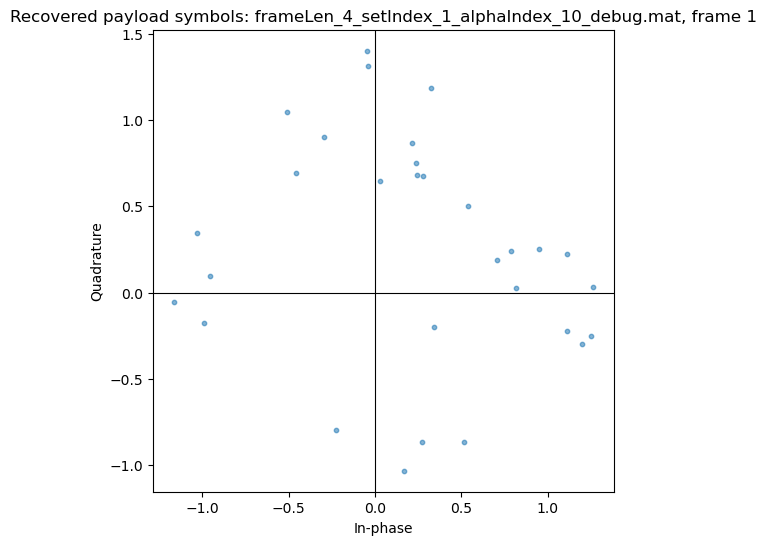

In [59]:
def debug_field(debug_obj, name):
    if isinstance(debug_obj, dict):
        return debug_obj[name]
    return getattr(debug_obj, name)


if not debug_mat_files:
    print("No symbol-level debug MAT files found yet.")
else:
    try:
        sample_mat = loadmat(debug_mat_files[0], squeeze_me=True, simplify_cells=True)
        debug_out = sample_mat["debugOut"]
        payload_cells = debug_field(debug_out, "rxSymsPayload")
        best_output = int(np.asarray(debug_field(debug_out, "bestOutputIndex")).ravel()[0]) - 1

        payload = np.asarray(payload_cells[0][best_output]).ravel()

        plt.figure(figsize=(6, 6))
        plt.scatter(payload.real, payload.imag, s=10, alpha=0.55)
        plt.axhline(0, color="black", linewidth=0.8)
        plt.axvline(0, color="black", linewidth=0.8)
        plt.gca().set_aspect("equal", adjustable="box")
        plt.title(f"Recovered payload symbols: {debug_mat_files[0].name}, frame 1")
        plt.xlabel("In-phase")
        plt.ylabel("Quadrature")
        plt.show()
    except Exception as exc:
        print("Could not load symbol-level MAT debug file:", exc)

In [60]:
feature_candidate_paths = [
    challenge_root / "separation_frame_features.csv",
    challenge_root / "frame_feature_summary.csv",
]
feature_path = next((path for path in feature_candidate_paths if path.exists()), None)

recovery_feature_df = pd.DataFrame()
model_feature_cols = []

if sep_frame_df.empty:
    print("Recovery-feature modeling will populate after per-frame debug CSVs are generated.")
elif feature_path is not None:
    frame_feature_df = pd.read_csv(feature_path)
    merge_keys = ["alphaIndex", "frameLen", "setIndex", "frame_number"]
    recovery_feature_df = sep_frame_df.merge(frame_feature_df, on=merge_keys, how="inner")

    blocked_cols = set(merge_keys + ["success", "best_num_errors", "best_output_index"])
    model_feature_cols = [
        col for col in recovery_feature_df.select_dtypes(include=[np.number]).columns
        if col not in blocked_cols
    ]
    print("Merged MATLAB recovery labels with Python frame features:", recovery_feature_df.shape)
elif not sep_output_df.empty:
    merge_keys = ["alphaIndex", "frameLen", "setIndex", "frame_number"]
    best_output_rows = (
        sep_output_df
        .sort_values("numErrors")
        .groupby(merge_keys, as_index=False)
        .head(1)
    )
    constellation_cols = ["payload_mean_abs", "payload_std_abs", "payload_phase_std", "payload_power_mean"]
    recovery_feature_df = sep_frame_df.merge(best_output_rows[merge_keys + constellation_cols], on=merge_keys, how="left")
    model_feature_cols = constellation_cols
    print("Using debug-derived constellation summary features until an external frame-feature CSV is available.")

if not recovery_feature_df.empty:
    print("Candidate model features:", model_feature_cols)
    display(recovery_feature_df.head())

Merged MATLAB recovery labels with Python frame features: (1500, 55)
Candidate model features: ['n_samples_per_channel', 'ch1_power', 'ch1_amp_mean', 'ch1_amp_std', 'ch1_amp_max', 'ch1_papr', 'ch2_power', 'ch2_amp_mean', 'ch2_amp_std', 'ch2_amp_max', 'ch2_papr', 'ch3_power', 'ch3_amp_mean', 'ch3_amp_std', 'ch3_amp_max', 'ch3_papr', 'ch4_power', 'ch4_amp_mean', 'ch4_amp_std', 'ch4_amp_max', 'ch4_papr', 'power_mean', 'power_std', 'power_max', 'amp_mean_all', 'amp_std_all', 'amp_max_all', 'cov_eig_1', 'cov_eig_2', 'cov_eig_3', 'cov_eig_4', 'cov_trace', 'cov_condition', 'offdiag_cov_abs_mean', 'offdiag_cov_abs_std', 'offdiag_cov_abs_max', 'coherence_mean', 'coherence_std', 'coherence_max', 'spec_entropy_mean', 'spec_entropy_std', 'spec_flatness_mean', 'spec_flatness_std', 'spec_centroid_mean', 'spec_centroid_std', 'spec_bandwidth_mean', 'spec_bandwidth_std']


,alphaIndex,frameLen,setIndex,frame_number,best_output_index,best_num_errors,success,source_file,n_samples_per_channel,ch1_power,...,coherence_std,coherence_max,spec_entropy_mean,spec_entropy_std,spec_flatness_mean,spec_flatness_std,spec_centroid_mean,spec_centroid_std,spec_bandwidth_mean,spec_bandwidth_std
0,10,4,1,1,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,2.165391,...,0.142703,0.399508,4.251977,0.057244,0.546171,0.047234,-0.055337,0.035518,0.271606,0.009331
1,10,4,1,2,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,2.324642,...,0.168710,0.454830,4.220219,0.084112,0.510523,0.048820,-0.014543,0.030964,0.281135,0.008781
2,10,4,1,3,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,3.629893,...,0.158961,0.428296,4.280434,0.024807,0.580396,0.025518,-0.041344,0.010818,0.278740,0.017215
3,10,4,1,4,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,2.152381,...,0.122101,0.343138,4.227621,0.044936,0.533771,0.044401,-0.013924,0.016695,0.281625,0.004149
4,10,4,1,5,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,1.961137,...,0.094016,0.376667,4.246631,0.013631,0.550149,0.019775,0.004846,0.011220,0.286573,0.013596


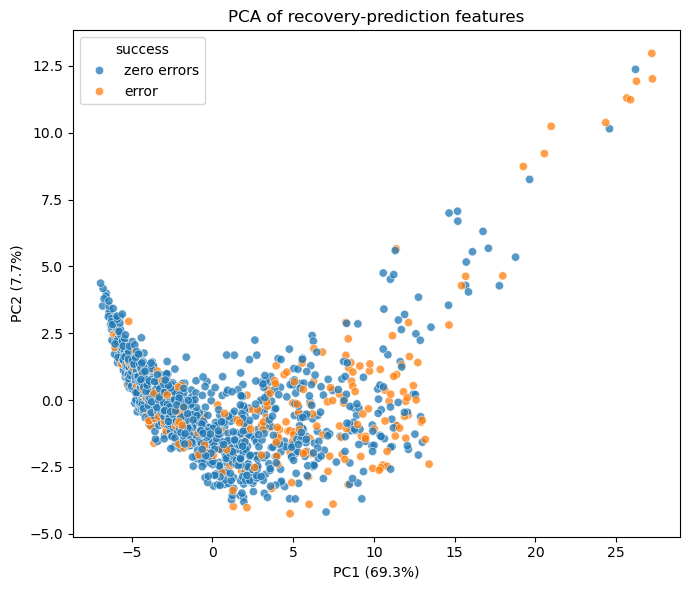

,Model,Mean CV Accuracy,Std CV Accuracy
0,LDA,0.8040,0.0174
1,QDA,0.7813,0.0176
2,Logistic,0.8100,0.0146


In [61]:
if recovery_feature_df.empty or not model_feature_cols:
    print("No recovery feature table is available for PCA/classification yet.")
else:
    X_rec = recovery_feature_df[model_feature_cols].replace([np.inf, -np.inf], np.nan)
    X_rec = X_rec.dropna(axis=0)
    y_rec = recovery_feature_df.loc[X_rec.index, "success"].astype(int)

    if y_rec.nunique() < 2:
        print("Need both successful and failed frames before fitting recovery classifiers.")
    elif len(X_rec) < 10:
        print("Need at least 10 complete debug rows before fitting recovery classifiers.")
    else:
        X_rec_scaled = StandardScaler().fit_transform(X_rec)
        n_components = min(2, X_rec.shape[1])
        pca_rec = PCA(n_components=n_components)
        Z_rec = pca_rec.fit_transform(X_rec_scaled)

        pca_rec_df = pd.DataFrame({
            "PC1": Z_rec[:, 0],
            "PC2": Z_rec[:, 1] if n_components > 1 else 0.0,
            "success": y_rec.map({0: "error", 1: "zero errors"}).values,
        })

        plt.figure(figsize=(7, 6))
        sns.scatterplot(data=pca_rec_df, x="PC1", y="PC2", hue="success", alpha=0.75)
        plt.title("PCA of recovery-prediction features")
        plt.xlabel(f"PC1 ({pca_rec.explained_variance_ratio_[0]:.1%})")
        plt.ylabel(f"PC2 ({pca_rec.explained_variance_ratio_[1]:.1%})" if n_components > 1 else "PC2")
        plt.tight_layout()
        plt.show()

        min_class_count = y_rec.value_counts().min()
        if min_class_count < 2:
            print("Cross-validation skipped because one class has fewer than two frames.")
        else:
            n_splits = min(5, int(min_class_count))
            cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
            recovery_models = {
                "LDA": LinearDiscriminantAnalysis(),
                "QDA": QuadraticDiscriminantAnalysis(reg_param=0.05),
                "Logistic": LogisticRegression(max_iter=2000),
            }

            recovery_scores = []
            for name, model in recovery_models.items():
                scores = cross_val_score(model, X_rec_scaled, y_rec, cv=cv, scoring="accuracy")
                recovery_scores.append({
                    "Model": name,
                    "Mean CV Accuracy": scores.mean(),
                    "Std CV Accuracy": scores.std(),
                })

            display(pd.DataFrame(recovery_scores).round(4))

# Part C: Recovery-Side Analysis

This section joins the Octave debug recovery outputs with frame-level mixture features from `separation_frame_features.csv`. It focuses on which multivariate mixture statistics are associated with successful symbol recovery after separation.

In [62]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

challenge_root = Path(r"D:\CS 6955\CS-6955\DL-AIR\mit_challenge")
debug_root = challenge_root / "debugEval"
frame_feature_path = challenge_root / "separation_frame_features.csv"
merge_keys = ["alphaIndex", "frameLen", "setIndex", "frame_number"]

def load_debug_csvs(paths):
    if not paths:
        return pd.DataFrame()
    tables = []
    for path in paths:
        table = pd.read_csv(path)
        table["source_file"] = path.name
        tables.append(table)
    return pd.concat(tables, ignore_index=True)

def normalize_key_columns(table):
    for col in merge_keys + ["success", "best_output_index", "output_index"]:
        if col in table.columns:
            table[col] = pd.to_numeric(table[col], errors="coerce").astype("Int64")
    return table

per_frame_files = sorted(debug_root.glob("*_perFrame.csv"))
per_output_files = sorted(debug_root.glob("*_perOutput.csv"))
debug_mat_files = sorted(debug_root.glob("*_debug.mat"))

sep_frame_df = normalize_key_columns(load_debug_csvs(per_frame_files))
sep_output_df = normalize_key_columns(load_debug_csvs(per_output_files))
frame_feature_df = pd.read_csv(frame_feature_path) if frame_feature_path.exists() else pd.DataFrame()
frame_feature_df = normalize_key_columns(frame_feature_df) if not frame_feature_df.empty else frame_feature_df

if sep_frame_df.empty:
    print("No per-frame recovery CSVs found in", debug_root)
if sep_output_df.empty:
    print("No per-output recovery CSVs found in", debug_root)
if frame_feature_df.empty:
    print("No frame feature CSV found at", frame_feature_path)

if not sep_frame_df.empty and not frame_feature_df.empty:
    recovery_feature_df = sep_frame_df.merge(frame_feature_df, on=merge_keys, how="inner")
else:
    recovery_feature_df = pd.DataFrame()

print("per-frame files:", len(per_frame_files))
print("per-output files:", len(per_output_files))
print("debug MAT files:", len(debug_mat_files))
print("sep_frame_df shape:", sep_frame_df.shape)
print("sep_output_df shape:", sep_output_df.shape)
print("frame_feature_df shape:", frame_feature_df.shape)
print("recovery_feature_df shape:", recovery_feature_df.shape)

if not sep_frame_df.empty:
    print("sep_frame_df columns:")
    print(list(sep_frame_df.columns))
    display(sep_frame_df.head())

if not sep_output_df.empty:
    print("sep_output_df columns:")
    print(list(sep_output_df.columns))
    display(sep_output_df.head())

if not recovery_feature_df.empty:
    print("recovery_feature_df columns:")
    print(list(recovery_feature_df.columns))
    display(recovery_feature_df.head())
    print("success counts:")
    print(recovery_feature_df["success"].value_counts(dropna=False).sort_index())

per-frame files: 15
per-output files: 15
debug MAT files: 15
sep_frame_df shape: (1500, 8)
sep_output_df shape: (3000, 12)
frame_feature_df shape: (1500, 51)
recovery_feature_df shape: (1500, 55)
sep_frame_df columns:
['alphaIndex', 'frameLen', 'setIndex', 'frame_number', 'best_output_index', 'best_num_errors', 'success', 'source_file']


,alphaIndex,frameLen,setIndex,frame_number,best_output_index,best_num_errors,success,source_file
0,10,4,1,1,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
1,10,4,1,2,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
2,10,4,1,3,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
3,10,4,1,4,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
4,10,4,1,5,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv


sep_output_df columns:
['alphaIndex', 'frameLen', 'setIndex', 'frame_number', 'output_index', 'numErrors', 'success', 'payload_mean_abs', 'payload_std_abs', 'payload_phase_std', 'payload_power_mean', 'source_file']


,alphaIndex,frameLen,setIndex,frame_number,output_index,numErrors,success,payload_mean_abs,payload_std_abs,payload_phase_std,payload_power_mean,source_file
0,10,4,1,1,1,0,1,0.973549,0.232385,1.529508,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
1,10,4,1,1,2,7,0,0.873792,0.494613,1.956597,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
2,10,4,1,2,1,0,1,0.984177,0.180218,2.153285,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
3,10,4,1,2,2,4,0,0.925038,0.386369,2.179054,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
4,10,4,1,3,1,0,1,0.987049,0.163165,1.851892,1,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv


recovery_feature_df columns:
['alphaIndex', 'frameLen', 'setIndex', 'frame_number', 'best_output_index', 'best_num_errors', 'success', 'source_file', 'n_samples_per_channel', 'ch1_power', 'ch1_amp_mean', 'ch1_amp_std', 'ch1_amp_max', 'ch1_papr', 'ch2_power', 'ch2_amp_mean', 'ch2_amp_std', 'ch2_amp_max', 'ch2_papr', 'ch3_power', 'ch3_amp_mean', 'ch3_amp_std', 'ch3_amp_max', 'ch3_papr', 'ch4_power', 'ch4_amp_mean', 'ch4_amp_std', 'ch4_amp_max', 'ch4_papr', 'power_mean', 'power_std', 'power_max', 'amp_mean_all', 'amp_std_all', 'amp_max_all', 'cov_eig_1', 'cov_eig_2', 'cov_eig_3', 'cov_eig_4', 'cov_trace', 'cov_condition', 'offdiag_cov_abs_mean', 'offdiag_cov_abs_std', 'offdiag_cov_abs_max', 'coherence_mean', 'coherence_std', 'coherence_max', 'spec_entropy_mean', 'spec_entropy_std', 'spec_flatness_mean', 'spec_flatness_std', 'spec_centroid_mean', 'spec_centroid_std', 'spec_bandwidth_mean', 'spec_bandwidth_std']


,alphaIndex,frameLen,setIndex,frame_number,best_output_index,best_num_errors,success,source_file,n_samples_per_channel,ch1_power,...,coherence_std,coherence_max,spec_entropy_mean,spec_entropy_std,spec_flatness_mean,spec_flatness_std,spec_centroid_mean,spec_centroid_std,spec_bandwidth_mean,spec_bandwidth_std
0,10,4,1,1,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,2.165391,...,0.142703,0.399508,4.251977,0.057244,0.546171,0.047234,-0.055337,0.035518,0.271606,0.009331
1,10,4,1,2,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,2.324642,...,0.168710,0.454830,4.220219,0.084112,0.510523,0.048820,-0.014543,0.030964,0.281135,0.008781
2,10,4,1,3,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,3.629893,...,0.158961,0.428296,4.280434,0.024807,0.580396,0.025518,-0.041344,0.010818,0.278740,0.017215
3,10,4,1,4,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,2.152381,...,0.122101,0.343138,4.227621,0.044936,0.533771,0.044401,-0.013924,0.016695,0.281625,0.004149
4,10,4,1,5,1,0,1,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv,111,1.961137,...,0.094016,0.376667,4.246631,0.013631,0.550149,0.019775,0.004846,0.011220,0.286573,0.013596


success counts:
success
0     280
1    1220
Name: count, dtype: Int64


,alphaIndex,frame_success_rate,mean_best_errors,n_frames
0,1,0.91,0.26,100
1,2,0.84,0.72,100
2,3,0.91,0.41,100
3,4,0.89,0.61,100
4,5,0.84,0.77,100
5,6,0.91,0.37,100
6,7,0.81,0.78,100
7,8,0.91,0.31,100
8,9,0.85,0.53,100
9,10,0.84,0.59,100


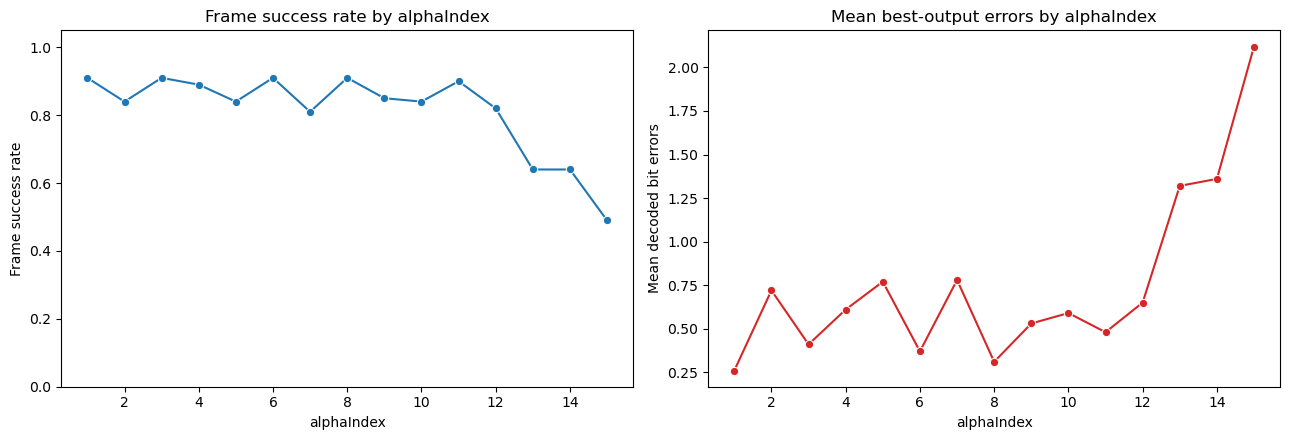

In [63]:
alpha_summary = pd.DataFrame()

if recovery_feature_df.empty:
    print("Skipping alpha-level recovery summaries because recovery_feature_df is empty.")
else:
    alpha_summary = (
        recovery_feature_df
        .groupby("alphaIndex", as_index=False)
        .agg(
            frame_success_rate=("success", "mean"),
            mean_best_errors=("best_num_errors", "mean"),
            n_frames=("frame_number", "count"),
        )
    )
    display(alpha_summary)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.lineplot(data=alpha_summary, x="alphaIndex", y="frame_success_rate", marker="o", ax=axes[0])
    axes[0].set_title("Frame success rate by alphaIndex")
    axes[0].set_xlabel("alphaIndex")
    axes[0].set_ylabel("Frame success rate")
    axes[0].set_ylim(0, 1.05)

    sns.lineplot(data=alpha_summary, x="alphaIndex", y="mean_best_errors", marker="o", color="tab:red", ax=axes[1])
    axes[1].set_title("Mean best-output errors by alphaIndex")
    axes[1].set_xlabel("alphaIndex")
    axes[1].set_ylabel("Mean decoded bit errors")

    plt.tight_layout()
    plt.show()

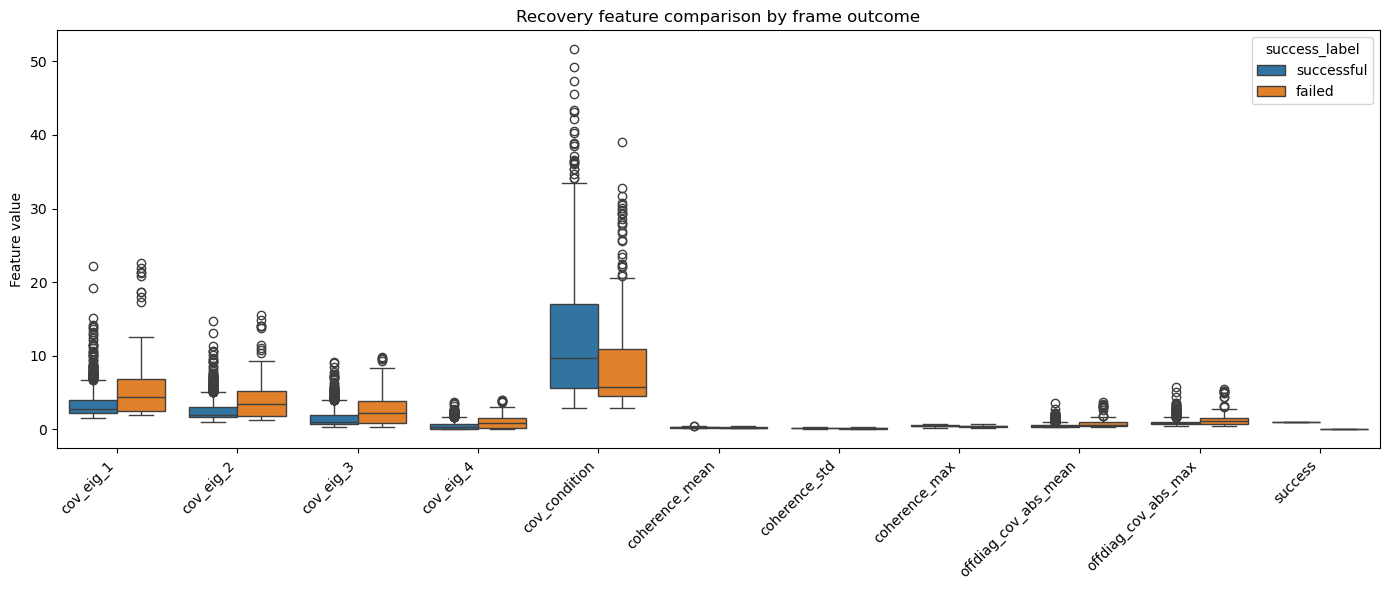

cov_eig_1         cov_eig_2         cov_eig_3         cov_eig_4  \
             mean     std      mean     std      mean     std      mean   
success                                                                   
0          5.1620  3.6280    3.8766  2.5427    2.5804  1.9641    0.9960   
1          3.5604  2.0408    2.6414  1.5500    1.5561  1.2907    0.5352   

                cov_condition         coherence_mean         coherence_std  \
            std          mean     std           mean     std          mean   
success                                                                      
0        0.8759        9.1547  7.2043         0.2693  0.0519        0.1521   
1        0.5773       12.3469  8.3096         0.2958  0.0536        0.1814   

                coherence_max         offdiag_cov_abs_mean          \
            std          mean     std                 mean     std   
success                                                              
0        0.0574        0.4510  0.1010               0.7871  0.5432   
1        0.0545        0.5048  0.0969               0.5650  0.2854   

        offdiag_cov_abs_max          
                       mean     std  
success                              
0                    1.3186  0.8562  
1                    0.9756  0.4721

In [64]:
candidate_recovery_features = [
    "cov_eig_1", "cov_eig_2", "cov_eig_3", "cov_eig_4", "cov_condition",
    "coherence_mean", "coherence_std", "coherence_max",
    "offdiag_cov_abs_mean", "offdiag_cov_abs_max",
    "spec_entropy_mean", "spec_flatness_mean", "spec_bandwidth_mean",
    "power_mean", "power_std", "power_max",
    "ch1_power", "ch2_power", "ch3_power", "ch4_power",
    "ch1_papr", "ch2_papr", "ch3_papr", "ch4_papr",
    "amp_std_all", "amp_max_all",
]

available_recovery_features = [col for col in candidate_recovery_features if col in recovery_feature_df.columns]

if recovery_feature_df.empty or not available_recovery_features:
    print("Skipping feature comparison because recovery features are unavailable.")
elif recovery_feature_df["success"].nunique() < 2:
    print("Only one success class is present; showing feature/error correlations instead of success/failure boxplots.")
    corr_table = (
        recovery_feature_df[available_recovery_features + ["best_num_errors"]]
        .corr(numeric_only=True)["best_num_errors"]
        .drop("best_num_errors")
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .head(12)
    )
    display(corr_table.to_frame("corr_with_best_num_errors"))
else:
    plot_features = available_recovery_features[:10]
    feature_long = recovery_feature_df[plot_features + ["success"]].copy()
    feature_long["success_label"] = feature_long["success"].map({0: "failed", 1: "successful"})
    feature_long = feature_long.melt(id_vars="success_label", var_name="feature", value_name="value")

    plt.figure(figsize=(14, 6))
    sns.boxplot(data=feature_long, x="feature", y="value", hue="success_label")
    plt.xticks(rotation=45, ha="right")
    plt.title("Recovery feature comparison by frame outcome")
    plt.xlabel("")
    plt.ylabel("Feature value")
    plt.tight_layout()
    plt.show()

    summary = recovery_feature_df.groupby("success")[plot_features].agg(["mean", "std"]).round(4)
    display(summary)

Recovery PCA explained variance ratio: [0.69328889 0.07696107]


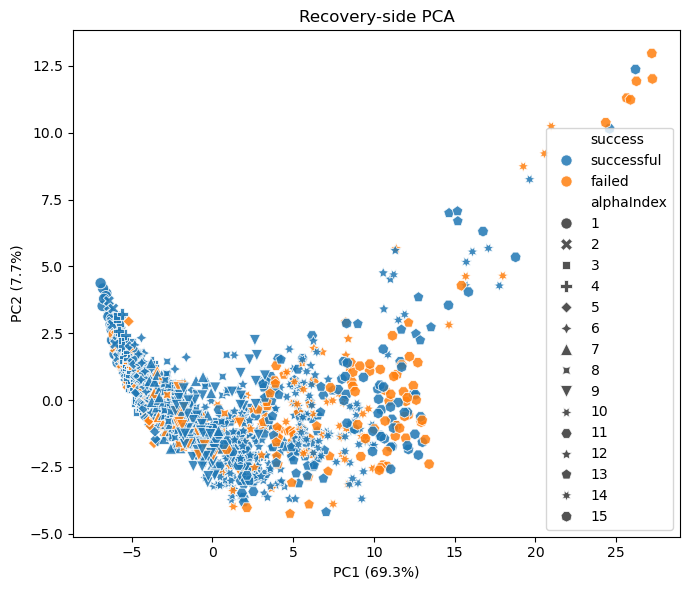

Top absolute loadings for PC1:


,PC1
amp_std_all,0.176212
amp_mean_all,0.175208
ch2_amp_mean,0.174090
ch2_amp_std,0.174090
ch1_amp_std,0.173891
ch3_amp_std,0.173827
ch4_amp_mean,0.173787
ch3_amp_mean,0.173750
ch1_amp_mean,0.173735
ch4_amp_std,0.173643


Top absolute loadings for PC2:


,PC2
offdiag_cov_abs_std,0.271730
cov_condition,0.266847
spec_centroid_std,-0.256943
coherence_mean,0.250245
ch1_papr,-0.247322
ch3_papr,-0.246011
coherence_max,0.246003
ch4_papr,-0.234817
coherence_std,0.229675
offdiag_cov_abs_max,0.214259


In [65]:
feature_cols_rec = []
pca_loadings_rec = pd.DataFrame()

if recovery_feature_df.empty:
    print("Skipping recovery PCA because recovery_feature_df is empty.")
else:
    excluded_cols = set(merge_keys + ["success", "best_num_errors", "best_output_index"])
    feature_cols_rec = [
        col for col in recovery_feature_df.select_dtypes(include=[np.number]).columns
        if col not in excluded_cols
    ]
    X_rec = recovery_feature_df[feature_cols_rec].replace([np.inf, -np.inf], np.nan).dropna(axis=0)
    y_rec = recovery_feature_df.loc[X_rec.index, "success"].astype(int)

    if X_rec.shape[0] < 2 or X_rec.shape[1] < 2:
        print("Need at least two rows and two numeric features for recovery PCA.")
    else:
        X_rec_scaled = StandardScaler().fit_transform(X_rec)
        pca_rec = PCA(n_components=2, random_state=42)
        Z_rec = pca_rec.fit_transform(X_rec_scaled)
        pca_rec_df = pd.DataFrame({
            "PC1": Z_rec[:, 0],
            "PC2": Z_rec[:, 1],
            "success": y_rec.map({0: "failed", 1: "successful"}).values,
            "alphaIndex": recovery_feature_df.loc[X_rec.index, "alphaIndex"].astype(int).values,
        })

        print("Recovery PCA explained variance ratio:", pca_rec.explained_variance_ratio_)

        plt.figure(figsize=(7, 6))
        sns.scatterplot(data=pca_rec_df, x="PC1", y="PC2", hue="success", style="alphaIndex", s=65, alpha=0.85)
        plt.title("Recovery-side PCA")
        plt.xlabel(f"PC1 ({pca_rec.explained_variance_ratio_[0]:.1%})")
        plt.ylabel(f"PC2 ({pca_rec.explained_variance_ratio_[1]:.1%})")
        plt.tight_layout()
        plt.show()

        pca_loadings_rec = pd.DataFrame(
            pca_rec.components_.T,
            index=feature_cols_rec,
            columns=["PC1", "PC2"],
        )
        top_pc1 = pca_loadings_rec["PC1"].abs().sort_values(ascending=False).head(10).index
        top_pc2 = pca_loadings_rec["PC2"].abs().sort_values(ascending=False).head(10).index

        print("Top absolute loadings for PC1:")
        display(pca_loadings_rec.loc[top_pc1, ["PC1"]].sort_values("PC1", key=lambda s: s.abs(), ascending=False))
        print("Top absolute loadings for PC2:")
        display(pca_loadings_rec.loc[top_pc2, ["PC2"]].sort_values("PC2", key=lambda s: s.abs(), ascending=False))

Eight strongest recovery-side PCA-loading features:


,max_abs_loading_PC1_PC2
offdiag_cov_abs_std,0.271730
cov_condition,0.266847
spec_centroid_std,0.256943
coherence_mean,0.250245
ch1_papr,0.247322
ch3_papr,0.246011
coherence_max,0.246003
ch4_papr,0.234817


Features plotted: ['offdiag_cov_abs_std', 'cov_condition', 'spec_centroid_std', 'coherence_mean']


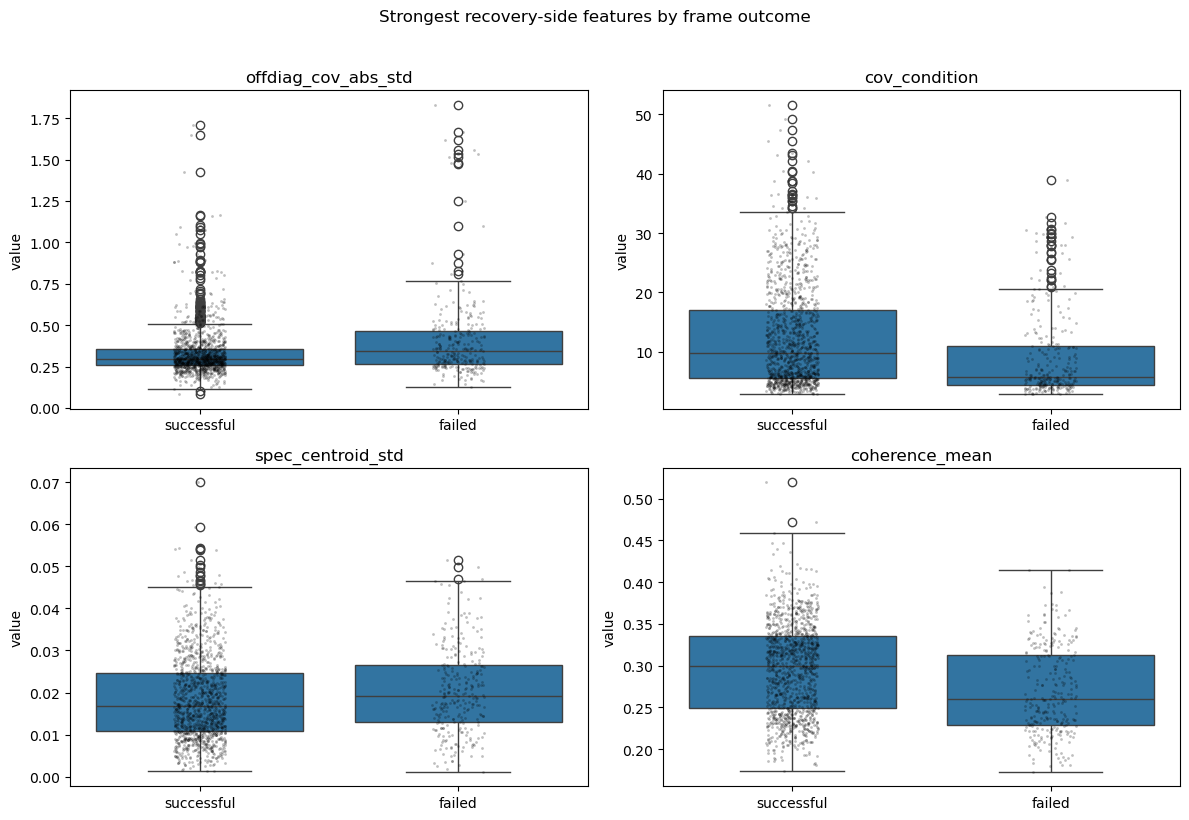

In [66]:
strongest_recovery_features = []
plotted_recovery_features = []

if recovery_feature_df.empty or pca_loadings_rec.empty:
    print("Skipping strongest-feature plots because PCA loadings are unavailable.")
else:
    loading_strength = pca_loadings_rec.abs().max(axis=1).sort_values(ascending=False)
    strongest_recovery_features = loading_strength.head(8).index.tolist()
    plotted_recovery_features = strongest_recovery_features[:4]

    print("Eight strongest recovery-side PCA-loading features:")
    display(loading_strength.head(8).to_frame("max_abs_loading_PC1_PC2"))
    print("Features plotted:", plotted_recovery_features)

    if recovery_feature_df["success"].nunique() < 2:
        print("Only one success class is present; skipping success-vs-failure boxplots.")
    else:
        plot_df = recovery_feature_df[plotted_recovery_features + ["success"]].copy()
        plot_df["success_label"] = plot_df["success"].map({0: "failed", 1: "successful"})

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes = axes.ravel()
        for ax, feature in zip(axes, plotted_recovery_features):
            sns.boxplot(data=plot_df, x="success_label", y=feature, ax=ax)
            sns.stripplot(data=plot_df, x="success_label", y=feature, color="black", alpha=0.25, size=2, ax=ax)
            ax.set_title(feature)
            ax.set_xlabel("")
            ax.set_ylabel("value")

        plt.suptitle("Strongest recovery-side features by frame outcome", y=1.02)
        plt.tight_layout()
        plt.show()

In [67]:
recovery_model_results = pd.DataFrame()

if recovery_feature_df.empty or not feature_cols_rec:
    print("Skipping recovery-side supervised models because recovery features are unavailable.")
else:
    X_model = recovery_feature_df[feature_cols_rec].replace([np.inf, -np.inf], np.nan).dropna(axis=0)
    y_model = recovery_feature_df.loc[X_model.index, "success"].astype(int)

    if y_model.nunique() < 2 or y_model.value_counts().min() < 2:
        print("Classification skipped because success labels are one-class or too imbalanced for stratified CV.")
        error_corr = (
            recovery_feature_df[feature_cols_rec + ["best_num_errors"]]
            .corr(numeric_only=True)["best_num_errors"]
            .drop("best_num_errors")
            .sort_values(key=lambda s: s.abs(), ascending=False)
            .head(12)
        )
        print("Fallback: strongest absolute correlations with best_num_errors")
        display(error_corr.to_frame("corr_with_best_num_errors"))
    else:
        X_model_scaled = StandardScaler().fit_transform(X_model)
        n_splits = min(5, int(y_model.value_counts().min()))
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        models = {
            "LDA": LinearDiscriminantAnalysis(),
            "QDA": QuadraticDiscriminantAnalysis(reg_param=0.05),
            "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
        }

        rows = []
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            for name, model in models.items():
                scores = cross_val_score(model, X_model_scaled, y_model, cv=cv, scoring="accuracy")
                rows.append({
                    "Model": name,
                    "Mean CV Accuracy": scores.mean(),
                    "Std CV Accuracy": scores.std(),
                })

        recovery_model_results = pd.DataFrame(rows).round(4)
        display(recovery_model_results)

,Model,Mean CV Accuracy,Std CV Accuracy
0,LDA,0.8040,0.0174
1,QDA,0.7813,0.0176
2,Logistic Regression,0.6873,0.0167


Grouped output summaries:


,output_index,success,n_rows,mean_errors,median_errors,mean_payload_std_abs,mean_payload_phase_std
0,1,0,564,6.166667,6.0,0.428637,1.790614
1,1,1,936,0.000000,0.0,0.208481,1.839295
2,2,0,1204,8.382890,9.0,0.449650,1.802158
3,2,1,296,0.000000,0.0,0.270191,1.833936


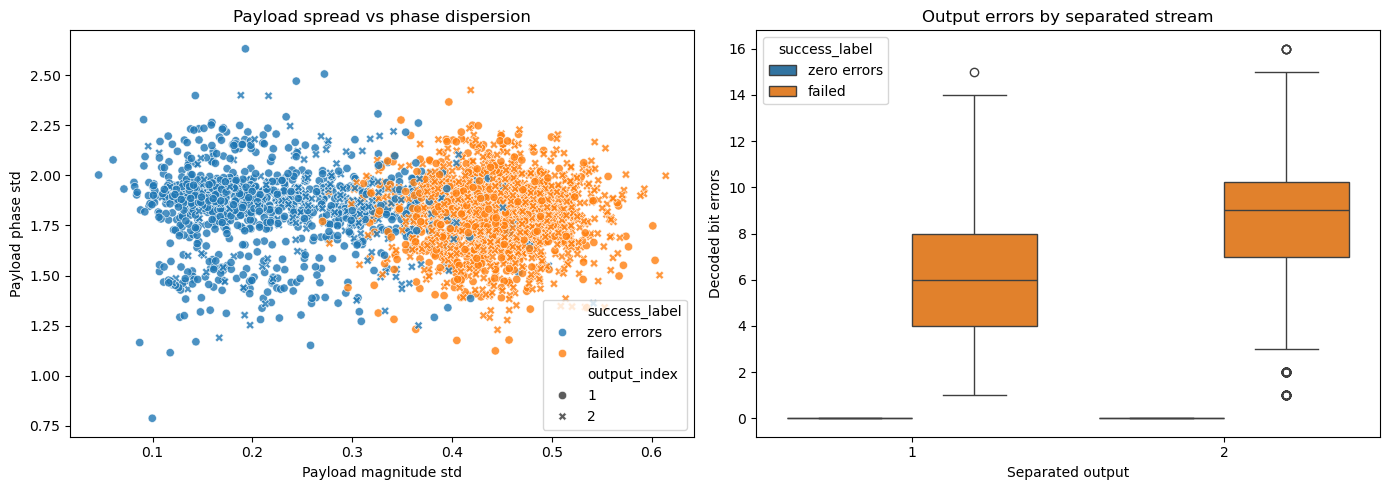

In [68]:
if sep_output_df.empty:
    print("Skipping output-level recovery analysis because sep_output_df is empty.")
else:
    output_plot_df = sep_output_df.copy()
    output_plot_df["success_label"] = output_plot_df["success"].map({0: "failed", 1: "zero errors"})

    print("Grouped output summaries:")
    output_summary = (
        output_plot_df
        .groupby(["output_index", "success"], as_index=False)
        .agg(
            n_rows=("frame_number", "count"),
            mean_errors=("numErrors", "mean"),
            median_errors=("numErrors", "median"),
            mean_payload_std_abs=("payload_std_abs", "mean"),
            mean_payload_phase_std=("payload_phase_std", "mean"),
        )
    )
    display(output_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.scatterplot(
        data=output_plot_df,
        x="payload_std_abs",
        y="payload_phase_std",
        hue="success_label",
        style="output_index",
        alpha=0.8,
        ax=axes[0],
    )
    axes[0].set_title("Payload spread vs phase dispersion")
    axes[0].set_xlabel("Payload magnitude std")
    axes[0].set_ylabel("Payload phase std")

    sns.boxplot(data=output_plot_df, x="output_index", y="numErrors", hue="success_label", ax=axes[1])
    axes[1].set_title("Output errors by separated stream")
    axes[1].set_xlabel("Separated output")
    axes[1].set_ylabel("Decoded bit errors")

    plt.tight_layout()
    plt.show()

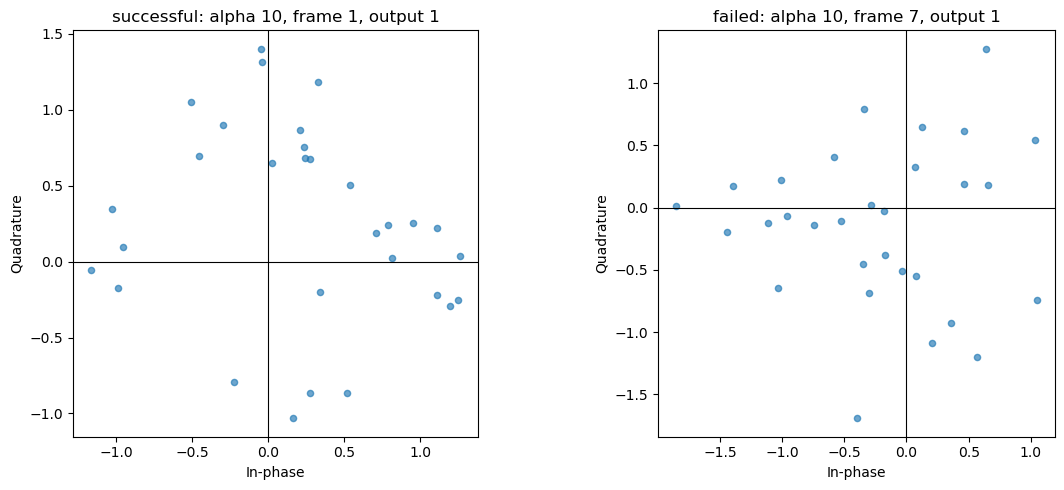

In [69]:
def debug_field(debug_obj, name, default=None):
    if isinstance(debug_obj, dict):
        return debug_obj.get(name, default)
    return getattr(debug_obj, name, default)

def payload_at(payload_cells, frame_idx, output_idx):
    try:
        return np.asarray(payload_cells[frame_idx, output_idx]).ravel()
    except Exception:
        return np.asarray(payload_cells[frame_idx][output_idx]).ravel()

def find_constellation_example(target_success=None):
    for mat_path in debug_mat_files:
        try:
            debug_obj = loadmat(mat_path, squeeze_me=True, simplify_cells=True)["debugOut"]
            success_vec = np.asarray(debug_field(debug_obj, "success")).astype(int).ravel()
            best_outputs = np.asarray(debug_field(debug_obj, "bestOutputIndex")).astype(int).ravel()
            payload_cells = debug_field(debug_obj, "rxSymsPayload")
            alpha_index = int(np.asarray(debug_field(debug_obj, "alphaIndex")).ravel()[0])

            for frame_idx, success_val in enumerate(success_vec):
                if target_success is None or success_val == target_success:
                    output_idx = max(0, best_outputs[frame_idx] - 1)
                    payload = payload_at(payload_cells, frame_idx, output_idx)
                    return {
                        "mat_path": mat_path,
                        "alphaIndex": alpha_index,
                        "frame_number": frame_idx + 1,
                        "output_index": output_idx + 1,
                        "success": int(success_val),
                        "payload": payload,
                    }
        except Exception as exc:
            print(f"Could not inspect {mat_path.name}: {exc}")
    return None

if not debug_mat_files:
    print("No debug MAT files available for constellation inspection.")
else:
    examples = [find_constellation_example(1), find_constellation_example(0)]
    examples = [example for example in examples if example is not None]

    if not examples:
        print("No constellation examples could be extracted from the debug MAT files.")
    else:
        fig, axes = plt.subplots(1, len(examples), figsize=(6 * len(examples), 5))
        if len(examples) == 1:
            axes = [axes]

        for ax, example in zip(axes, examples):
            payload = example["payload"]
            ax.scatter(payload.real, payload.imag, s=20, alpha=0.65)
            ax.axhline(0, color="black", linewidth=0.8)
            ax.axvline(0, color="black", linewidth=0.8)
            ax.set_aspect("equal", adjustable="box")
            label = "successful" if example["success"] == 1 else "failed"
            ax.set_title(
                f"{label}: alpha {example['alphaIndex']}, frame {example['frame_number']}, output {example['output_index']}"
            )
            ax.set_xlabel("In-phase")
            ax.set_ylabel("Quadrature")

        plt.tight_layout()
        plt.show()

# Part D: Learned Separator MIT Evaluation

This section reads MIT debug-evaluation outputs for the FastICA baseline and learned separator runs. It keeps the backend evaluation chain unchanged: learned models write MIT-compatible `outputA` / `outputB` files, then Octave produces the same per-frame, per-output, and MAT debug artifacts used above.


In [70]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

challenge_root = Path(r"D:\CS 6955\CS-6955\DL-AIR\mit_challenge")
merge_keys = ["alphaIndex", "frameLen", "setIndex", "frame_number"]
feature_path = challenge_root / "separation_frame_features.csv"

baseline_debug_dir = challenge_root / "debugEval"
learned_debug_dirs = sorted(challenge_root.glob("debugEval_learned_*"))
mit_debug_sources = [("FastICA", baseline_debug_dir)] + [
    (path.name.replace("debugEval_learned_", "Learned: "), path)
    for path in learned_debug_dirs
]

def normalize_key_columns(table):
    for col in merge_keys + ["success", "best_output_index", "output_index"]:
        if col in table.columns:
            table[col] = pd.to_numeric(table[col], errors="coerce").astype("Int64")
    return table

def load_debug_table(paths, separator):
    tables = []
    for path in paths:
        try:
            table = pd.read_csv(path)
            table["separator"] = separator
            table["source_file"] = path.name
            tables.append(normalize_key_columns(table))
        except Exception as exc:
            print(f"Could not read {path}: {exc}")
    return pd.concat(tables, ignore_index=True) if tables else pd.DataFrame()

def load_summary_table(path, separator):
    if not path.exists():
        return pd.DataFrame()
    try:
        summary = pd.read_csv(path)
        summary["separator"] = separator
        return summary
    except Exception as exc:
        print(f"Could not read {path}: {exc}")
        return pd.DataFrame()

frame_tables = []
output_tables = []
summary_tables = []
for separator, debug_dir in mit_debug_sources:
    if not debug_dir.exists():
        print(f"Missing debug directory for {separator}: {debug_dir}")
        continue
    per_frame_files = sorted(debug_dir.glob("*_perFrame.csv"))
    per_output_files = sorted(debug_dir.glob("*_perOutput.csv"))
    print(f"{separator}: {len(per_frame_files)} per-frame CSVs, {len(per_output_files)} per-output CSVs")
    frame_tables.append(load_debug_table(per_frame_files, separator))
    output_tables.append(load_debug_table(per_output_files, separator))
    summary_tables.append(load_summary_table(debug_dir / "debug_run_summary.csv", separator))

mit_eval_frame_df = pd.concat([table for table in frame_tables if not table.empty], ignore_index=True) if frame_tables else pd.DataFrame()
mit_eval_output_df = pd.concat([table for table in output_tables if not table.empty], ignore_index=True) if output_tables else pd.DataFrame()
mit_eval_summary_df = pd.concat([table for table in summary_tables if not table.empty], ignore_index=True) if summary_tables else pd.DataFrame()

frame_feature_df_mit = pd.read_csv(feature_path) if feature_path.exists() else pd.DataFrame()
if not frame_feature_df_mit.empty:
    frame_feature_df_mit = normalize_key_columns(frame_feature_df_mit)

if not mit_eval_frame_df.empty and not frame_feature_df_mit.empty:
    mit_recovery_feature_df = mit_eval_frame_df.merge(frame_feature_df_mit, on=merge_keys, how="inner")
else:
    mit_recovery_feature_df = pd.DataFrame()

print("mit_eval_frame_df shape:", mit_eval_frame_df.shape)
print("mit_eval_output_df shape:", mit_eval_output_df.shape)
print("mit_eval_summary_df shape:", mit_eval_summary_df.shape)
print("frame_feature_df_mit shape:", frame_feature_df_mit.shape)
print("mit_recovery_feature_df shape:", mit_recovery_feature_df.shape)

if not mit_eval_frame_df.empty:
    print("Frame columns:")
    print(list(mit_eval_frame_df.columns))
    print("Success counts by separator:")
    display(mit_eval_frame_df.groupby("separator")["success"].value_counts(dropna=False).unstack(fill_value=0))
    display(mit_eval_frame_df.head())

if not mit_eval_output_df.empty:
    print("Output columns:")
    print(list(mit_eval_output_df.columns))
    display(mit_eval_output_df.head())


FastICA: 15 per-frame CSVs, 15 per-output CSVs
Learned: HTDemucs: 1 per-frame CSVs, 1 per-output CSVs
Learned: Hybrid: 5 per-frame CSVs, 5 per-output CSVs
Learned: IQ_CNN: 1 per-frame CSVs, 1 per-output CSVs
Learned: LSTM: 1 per-frame CSVs, 1 per-output CSVs
mit_eval_frame_df shape: (2015, 9)
mit_eval_output_df shape: (4030, 13)
mit_eval_summary_df shape: (23, 6)
frame_feature_df_mit shape: (1500, 51)
mit_recovery_feature_df shape: (2015, 56)
Frame columns:
['alphaIndex', 'frameLen', 'setIndex', 'frame_number', 'best_output_index', 'best_num_errors', 'success', 'separator', 'source_file']
Success counts by separator:


success,0,1
separator,,
FastICA,280,1220
Learned: HTDemucs,5,0
Learned: Hybrid,500,0
Learned: IQ_CNN,5,0
Learned: LSTM,5,0


,alphaIndex,frameLen,setIndex,frame_number,best_output_index,best_num_errors,success,separator,source_file
0,10,4,1,1,1,0,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
1,10,4,1,2,1,0,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
2,10,4,1,3,1,0,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
3,10,4,1,4,1,0,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv
4,10,4,1,5,1,0,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perFrame.csv


Output columns:
['alphaIndex', 'frameLen', 'setIndex', 'frame_number', 'output_index', 'numErrors', 'success', 'payload_mean_abs', 'payload_std_abs', 'payload_phase_std', 'payload_power_mean', 'separator', 'source_file']


,alphaIndex,frameLen,setIndex,frame_number,output_index,numErrors,success,payload_mean_abs,payload_std_abs,payload_phase_std,payload_power_mean,separator,source_file
0,10,4,1,1,1,0,1,0.973549,0.232385,1.529508,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
1,10,4,1,1,2,7,0,0.873792,0.494613,1.956597,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
2,10,4,1,2,1,0,1,0.984177,0.180218,2.153285,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
3,10,4,1,2,2,4,0,0.925038,0.386369,2.179054,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv
4,10,4,1,3,1,0,1,0.987049,0.163165,1.851892,1,FastICA,frameLen_4_setIndex_1_alphaIndex_10_perOutput.csv


,separator,alphaIndex,frame_success_rate,mean_best_errors,n_frames,ber
0,FastICA,1,0.91,0.26,100,0.0130
1,FastICA,2,0.84,0.72,100,0.0360
2,FastICA,3,0.91,0.41,100,0.0205
3,FastICA,4,0.89,0.61,100,0.0305
4,FastICA,5,0.84,0.77,100,0.0385
5,FastICA,6,0.91,0.37,100,0.0185
6,FastICA,7,0.81,0.78,100,0.0390
7,FastICA,8,0.91,0.31,100,0.0155
8,FastICA,9,0.85,0.53,100,0.0265
9,FastICA,10,0.84,0.59,100,0.0295


Compact comparison over common alphaIndex values: [1]


,separator,frame_success_rate,mean_best_errors,n_frames,alpha_min,alpha_max,mean_ber
0,FastICA,0.91,0.26,100,1,1,0.013
1,Learned: HTDemucs,0.0,7.00,5,1,1,0.350
2,Learned: Hybrid,0.0,8.74,100,1,1,0.437
3,Learned: IQ_CNN,0.0,9.80,5,1,1,0.490
4,Learned: LSTM,0.0,10.00,5,1,1,0.500


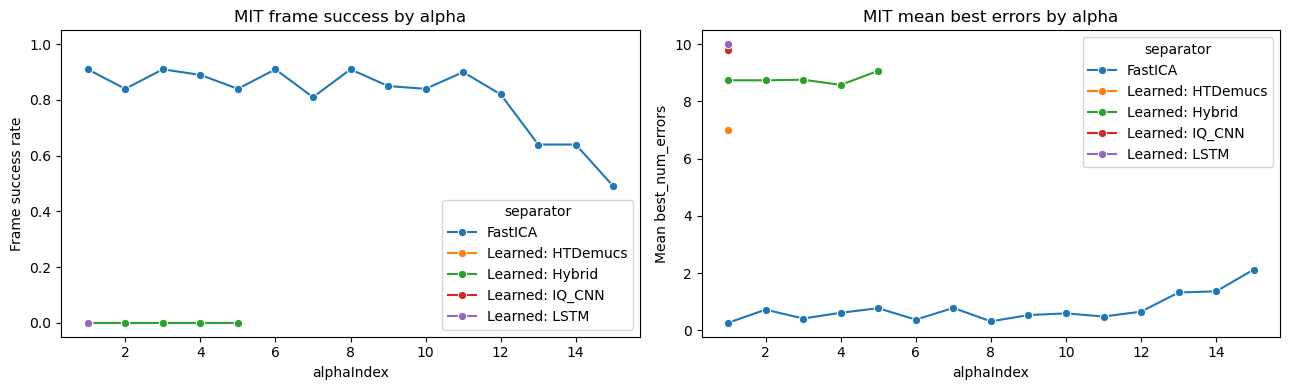

In [71]:
learned_alpha_summary = pd.DataFrame()
mit_separator_results = pd.DataFrame()

if mit_eval_frame_df.empty:
    print("Skipping learned-separator comparison because no MIT debug frame rows were found.")
else:
    learned_alpha_summary = (
        mit_eval_frame_df
        .groupby(["separator", "alphaIndex"], dropna=False)
        .agg(
            frame_success_rate=("success", "mean"),
            mean_best_errors=("best_num_errors", "mean"),
            n_frames=("frame_number", "count"),
        )
        .reset_index()
    )

    if not mit_eval_summary_df.empty and "ber" in mit_eval_summary_df.columns:
        ber_by_alpha = mit_eval_summary_df[["separator", "alphaIndex", "ber"]].copy()
        learned_alpha_summary = learned_alpha_summary.merge(
            ber_by_alpha,
            on=["separator", "alphaIndex"],
            how="left",
        )

    display(learned_alpha_summary.round(4))

    alpha_sets = [set(group["alphaIndex"].dropna().astype(int)) for _, group in mit_eval_frame_df.groupby("separator")]
    common_alphas = sorted(set.intersection(*alpha_sets)) if len(alpha_sets) > 1 else sorted(alpha_sets[0])
    comparison_scope = mit_eval_frame_df[mit_eval_frame_df["alphaIndex"].astype(int).isin(common_alphas)].copy()

    mit_separator_results = (
        comparison_scope
        .groupby("separator", dropna=False)
        .agg(
            frame_success_rate=("success", "mean"),
            mean_best_errors=("best_num_errors", "mean"),
            n_frames=("frame_number", "count"),
            alpha_min=("alphaIndex", "min"),
            alpha_max=("alphaIndex", "max"),
        )
        .reset_index()
    )

    if not mit_eval_summary_df.empty and "ber" in mit_eval_summary_df.columns and common_alphas:
        ber_scope = mit_eval_summary_df[mit_eval_summary_df["alphaIndex"].astype(int).isin(common_alphas)]
        ber_summary = ber_scope.groupby("separator", dropna=False).agg(mean_ber=("ber", "mean")).reset_index()
        mit_separator_results = mit_separator_results.merge(ber_summary, on="separator", how="left")

    print(f"Compact comparison over common alphaIndex values: {common_alphas}")
    display(mit_separator_results.round(4))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.lineplot(data=learned_alpha_summary, x="alphaIndex", y="frame_success_rate", hue="separator", marker="o", ax=axes[0])
    axes[0].set_title("MIT frame success by alpha")
    axes[0].set_ylabel("Frame success rate")
    axes[0].set_ylim(-0.05, 1.05)

    sns.lineplot(data=learned_alpha_summary, x="alphaIndex", y="mean_best_errors", hue="separator", marker="o", ax=axes[1])
    axes[1].set_title("MIT mean best errors by alpha")
    axes[1].set_ylabel("Mean best_num_errors")
    plt.tight_layout()
    plt.show()


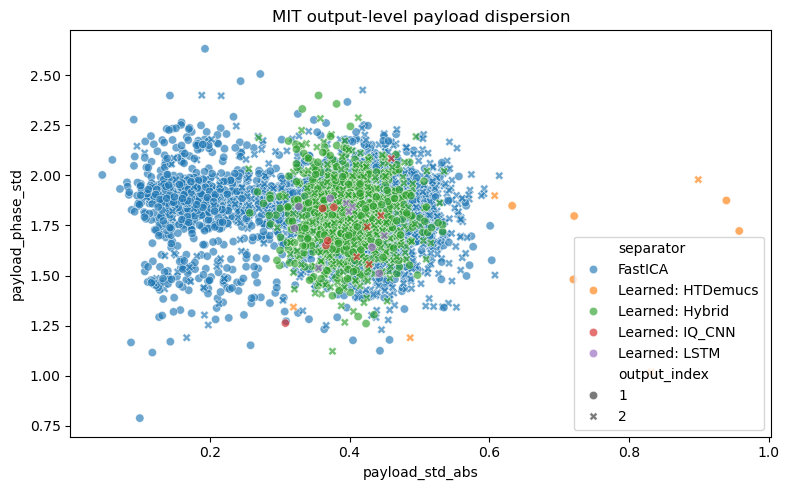

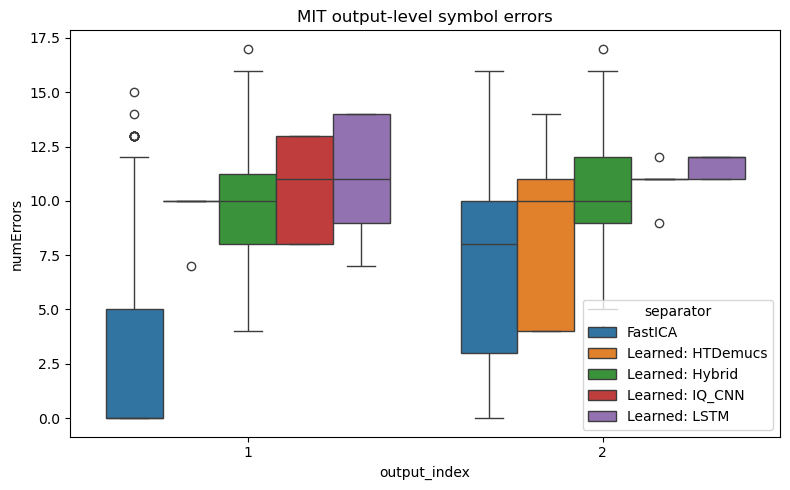

,separator,output_index,success,n_outputs,mean_numErrors,mean_payload_std_abs,mean_payload_phase_std
0,FastICA,1,0,564,6.1667,0.4286,1.7906
1,FastICA,1,1,936,0.0000,0.2085,1.8393
2,FastICA,2,0,1204,8.3829,0.4497,1.8022
3,FastICA,2,1,296,0.0000,0.2702,1.8339
4,Learned: HTDemucs,1,0,5,9.4000,0.7944,1.7445
5,Learned: HTDemucs,2,0,5,8.6000,0.6290,1.4857
6,Learned: Hybrid,1,0,500,9.9540,0.3933,1.8019
7,Learned: Hybrid,2,0,500,10.0200,0.4055,1.7854
8,Learned: IQ_CNN,1,0,5,10.6000,0.3564,1.6522
9,Learned: IQ_CNN,2,0,5,10.8000,0.4336,1.7550


In [72]:
if mit_eval_output_df.empty:
    print("Skipping learned output-level plots because no per-output rows were found.")
else:
    available_cols = set(mit_eval_output_df.columns)
    if {"payload_std_abs", "payload_phase_std", "success", "output_index", "separator"}.issubset(available_cols):
        plt.figure(figsize=(8, 5))
        sns.scatterplot(
            data=mit_eval_output_df,
            x="payload_std_abs",
            y="payload_phase_std",
            hue="separator",
            style="output_index",
            alpha=0.65,
        )
        plt.title("MIT output-level payload dispersion")
        plt.tight_layout()
        plt.show()

    if {"numErrors", "output_index", "separator"}.issubset(available_cols):
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=mit_eval_output_df, x="output_index", y="numErrors", hue="separator")
        plt.title("MIT output-level symbol errors")
        plt.tight_layout()
        plt.show()

    grouped_output_summary = (
        mit_eval_output_df
        .groupby(["separator", "output_index", "success"], dropna=False)
        .agg(
            n_outputs=("frame_number", "count"),
            mean_numErrors=("numErrors", "mean"),
            mean_payload_std_abs=("payload_std_abs", "mean"),
            mean_payload_phase_std=("payload_phase_std", "mean"),
        )
        .reset_index()
    )
    display(grouped_output_summary.round(4))
